In [10]:
from pathlib import Path

# === PARAMÈTRES ===
root = Path("/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/APX/limatch_F2B_v1")
output_file = Path("/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/APX/limatch_F2B_v1/LiDAR_p2p_test.txt")

# === RECHERCHE DES DOSSIERS cor_outputs ===
cor_dirs = sorted(p for p in root.rglob("cor_outputs") if p.is_dir())

# === RECHERCHE DES FICHIERS À MERGER ===
files_to_merge = []
for d in cor_dirs:
    files_to_merge.extend(sorted(d.glob("LiDAR_p2p_chunk*")))

files_to_merge = [f for f in files_to_merge if f.is_file()]

print(f"{len(files_to_merge)} fichiers trouvés.")

# === MERGE ===
output_file.parent.mkdir(parents=True, exist_ok=True)

with output_file.open("w", encoding="utf-8") as fout:
    for f in files_to_merge:
        with f.open("r", encoding="utf-8", errors="replace") as fin:
            content = fin.read()
            fout.write(content)
            if not content.endswith("\n"):
                fout.write("\n")

print(f"Merge terminé : {output_file}")

80 fichiers trouvés.
Merge terminé : /media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/APX/limatch_F2B_v1/LiDAR_p2p_test.txt


In [28]:
import numpy as np

f1 = "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/COMBINED/in/LiDAR_p2p.txt"
f2 = "/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/APX/georef_F2B/limatch_debug/9000_10000/cor_outputs/LiDAR_p2p.txt"
out = "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/COMBINED/in/LiDAR_p2p.txt"


a = np.loadtxt(f1, delimiter=",")
b = np.loadtxt(f2, delimiter=",")

print(f"File 1: {len(a)} lines")
print(f"File 2: {len(b)} lines")

merged = np.vstack([a, b])
merged = merged[np.argsort(merged[:, 0])]

print(f"Merged: {len(merged)} lines")

np.savetxt(out, merged, fmt="%.10f", delimiter=",")

File 1: 68333 lines
File 2: 1728 lines
Merged: 70061 lines


In [ ]:
from pathlib import Path
import subprocess
import shutil

# ============================================================
# INPUT
# ============================================================
root = Path("/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/s2s_chunks/")

# ============================================================
# FIND FILES
# seulement LiDAR_p2p_*.txt
# exclut LiDAR_p2p_rsc_*.txt
# ============================================================
files = sorted(
    f for f in root.rglob("LiDAR_p2p_*.txt")
    if not f.name.startswith("LiDAR_p2p_rsc_")
)

out_raw    = root / "LiDAR_p2p_merged_raw.txt"
out_clean  = root / "LiDAR_p2p_merged_clean.txt"
out_sorted = root / "LiDAR_p2p_merged_sorted.txt"

if not files:
    raise FileNotFoundError(f"Aucun fichier LiDAR_p2p_*.txt trouvé dans {root}")

print(f"{len(files)} fichier(s) trouvé(s)")
for f in files[:20]:
    print(" -", f)
if len(files) > 20:
    print(f" ... + {len(files)-20} autres")

# ============================================================
# MERGE
# ============================================================
with open(out_raw, "w") as fout:
    for f in files:
        with open(f, "r") as fin:
            for line in fin:
                if line.strip():
                    fout.write(line)

print(f"\nMerge brut écrit dans : {out_raw}")

# ============================================================
# CLEAN
# garde seulement les lignes dont la première colonne est numérique
# ============================================================
n_in, n_out, n_bad = 0, 0, 0

with open(out_raw, "r") as fin, open(out_clean, "w") as fout:
    for line in fin:
        n_in += 1
        s = line.strip()
        if not s:
            continue

        parts = s.replace(",", " ").split()
        if not parts:
            n_bad += 1
            continue

        try:
            float(parts[0])
            fout.write(line)
            n_out += 1
        except ValueError:
            n_bad += 1

print("\nNettoyage terminé")
print("  lignes lues    :", n_in)
print("  lignes gardées :", n_out)
print("  lignes rejetées:", n_bad)
print("Fichier clean :", out_clean)

# ============================================================
# SORT sur la première colonne
# ============================================================
if shutil.which("sort") is None:
    raise RuntimeError("La commande 'sort' n'est pas disponible sur ce système.")

cmd = f"sort -g -k1,1 '{out_clean}' > '{out_sorted}'"
subprocess.run(cmd, shell=True, check=True)

print(f"\nFichier final trié écrit dans : {out_sorted}")

161 fichier(s) trouvé(s)
 - /media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/s2s_chunks/limatch/Flights_10000_13000/Patch_from_scan_10000_with_13000_vs_Patch_from_scan_13000_with_10000/limatch/chunk_0001/cor_outputs/LiDAR_p2p_chunk_0001_chunk_0001.txt
 - /media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/s2s_chunks/limatch/Flights_10000_13000/Patch_from_scan_10000_with_13000_vs_Patch_from_scan_13000_with_10000/limatch/chunk_0002/cor_outputs/LiDAR_p2p_chunk_0002_chunk_0002.txt
 - /media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/s2s_chunks/limatch/Flights_10000_15000/Patch_from_scan_10000_with_15000_vs_Patch_from_scan_15000_with_10000/limatch/chunk_0001/cor_outputs/LiDAR_p2p_chunk_0001_chunk_0001.txt
 - /media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/s2s_chunks/limatch/Flights_10000_15000/Patch_from_scan_10000_with_15000_vs_Patch_from_scan_15000_with_10000/limatch/chunk_0002/cor_outputs/LiDAR_p2p_chunk_0002_chunk_0002.txt
 - /med

### stats success rate + nombre de chunks

In [ ]:
from pathlib import Path
import pandas as pd

BASE_PATH = "/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_1/limatch"
KEYWORD   = "LiDAR_p2p"
MIN_SIZE  = 1

def find_output_file(chunk_dir, keyword, min_size):
    cor_dir = chunk_dir / "cor_outputs"
    if not cor_dir.exists():
        return False, "pas de dossier cor_outputs"
    txt_files = list(cor_dir.glob("*.txt"))
    if not txt_files:
        return False, "aucun fichier .txt"
    if keyword:
        txt_files = [f for f in txt_files if keyword in f.name]
        if not txt_files:
            return False, f"aucun fichier contenant '{keyword}'"
    for f in txt_files:
        if f.stat().st_size >= min_size:
            return True, f.name
    return False, f"fichier(s) vide(s) (< {min_size} octets)"

records = []
for sensor_dir in sorted(Path(BASE_PATH).iterdir()):
    if not sensor_dir.is_dir():
        continue
    for chunk_dir in sorted(d for d in sensor_dir.iterdir() if d.is_dir()):
        success, detail = find_output_file(chunk_dir, KEYWORD, MIN_SIZE)
        records.append({"sensor": sensor_dir.name, "chunk": chunk_dir.name,
                        "success": success, "detail": detail})

df = pd.DataFrame(records)
print(f"Chunks trouvés : {len(df)}")

Chunks trouvés : 436


In [ ]:
total     = len(df)
n_success = df["success"].sum()
print(f"Total chunks   : {total}")
print(f"Réussis        : {n_success}")
print(f"Échoués        : {total - n_success}")
print(f"Success rate   : {n_success/total*100:.1f}%")

Total chunks   : 436
Réussis        : 337
Échoués        : 99
Success rate   : 77.3%


In [ ]:
df["status"] = df["success"].map({True: "✅", False: "❌"})
pd.set_option("display.max_rows", None)
df[["sensor", "chunk", "status", "detail"]]

,sensor,chunk,status,detail
0,merged_1000_VUX_PUCK,chunk_1000__chunk_1001,✅,LiDAR_p2p_rsc_chunk_1000_chunk_1001.txt
1,merged_1000_VUX_PUCK,chunk_1001__chunk_1002,❌,aucun fichier .txt
2,merged_1000_VUX_PUCK,chunk_1002__chunk_1003,❌,aucun fichier .txt
3,merged_1000_VUX_PUCK,chunk_1003__chunk_1004,✅,LiDAR_p2p_rsc_chunk_1003_chunk_1004.txt
4,merged_1000_VUX_PUCK,chunk_1004__chunk_1005,❌,aucun fichier .txt
5,merged_1000_VUX_PUCK,chunk_1005__chunk_1006,❌,aucun fichier .txt
6,merged_1000_VUX_PUCK,chunk_1006__chunk_1007,❌,aucun fichier .txt
7,merged_1000_VUX_PUCK,chunk_1007__chunk_1008,❌,aucun fichier .txt
8,merged_1000_VUX_PUCK,chunk_1008__chunk_1009,✅,LiDAR_p2p_rsc_chunk_1008_chunk_1009.txt
9,merged_1000_VUX_PUCK,chunk_1009__chunk_1010,✅,LiDAR_p2p_rsc_chunk_1009_chunk_1010.txt


In [ ]:
from pathlib import Path

roots = [
    #Path("/media/.../limatch"),
    Path("/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_ODyN/limatch_crossings_v2"),
]
out_file = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/outage_chunks/chunks_VUX_PUCK/hybrid/p2p_hybrid/LiDAR_p2p_all.txt")

with open(out_file, "w") as fout:

    for root in roots:
        files = sorted(root.rglob("LiDAR_p2p_chunk_*.txt"))
        files = [f for f in files if "_rsc_" not in f.name]
        for f in files:
            content = f.read_text()
            if content.strip():
                fout.write(content)
                if not content.endswith("\n"):
                    fout.write("\n")

print(f"Merged → {out_file}")

30
Merged → /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/outage_chunks/chunks_VUX_PUCK/hybrid/p2p_hybrid/LiDAR_p2p_all.txt


: 

In [ ]:
import numpy as np

file = "/media/b085164/Elements/PCD_SAM/village/merged/merged_800_HA_LR.txt"

data = np.loadtxt(file, delimiter=",")

n_points = data.shape[0]

t = data[:, 0]   # colonne 0 = GPS time
tmin = t.min()
tmax = t.max()

print("Number of points:", n_points)
print("tmin:", tmin)
print("tmax:", tmax)

Number of points: 210570172
tmin: 467364.851373258
tmax: 467573.346314613


: 

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# --- paths ---
in_path = Path("/media/b085164/Elements/Gobet_ODyN_v1/v4.2_GNSS_outage_limatch_kneighbor1/LiDAR_p2p.txt")      # <-- change to your file
out_path = in_path.with_name(in_path.stem + "_rotvec.txt")

# --- load (CSV with commas) ---
df = pd.read_csv(
    in_path,
    header=None,
    comment="#",
    skip_blank_lines=True
)

# expected columns:
# t_b, t_a, vec_b_x, vec_b_y, vec_b_z, vec_a_x, vec_a_y, vec_a_z
if df.shape[1] < 8:
    raise ValueError(f"Expected at least 8 columns, got {df.shape[1]}")

df = df.iloc[:, :8].copy()
df.columns = ["t_b","t_a","vec_b_x","vec_b_y","vec_b_z","vec_a_x","vec_a_y","vec_a_z"]

R = np.array([[0, 1, 0],
              [1, 0, 0],
              [0, 0,-1]], dtype=float)

# --- apply R to vec_b and vec_a ---
vb = df[["vec_b_x","vec_b_y","vec_b_z"]].to_numpy(float)
va = df[["vec_a_x","vec_a_y","vec_a_z"]].to_numpy(float)

vb_rot = (R @ vb.T).T
va_rot = (R @ va.T).T

df[["vec_b_x","vec_b_y","vec_b_z"]] = vb_rot
df[["vec_a_x","vec_a_y","vec_a_z"]] = va_rot

# --- save ---
df.to_csv(out_path, index=False, header=False, float_format="%.12f")
print("Wrote:", out_path)

# quick sanity check: show first rows
df.head()

Wrote: /media/b085164/Elements/Gobet_ODyN_v1/v4.2_GNSS_outage_limatch_kneighbor1/LiDAR_p2p_rotvec.txt


,t_b,t_a,vec_b_x,vec_b_y,vec_b_z,vec_a_x,vec_a_y,vec_a_z
0,466562.626260,466560.883635,6.6399,-9.8000,-1.4228,7.303,5.250,-1.850
1,466562.636280,466560.758630,7.0620,-10.0634,-1.2329,7.779,5.941,-1.695
2,466562.641253,466560.888630,6.6870,-9.9051,-1.4968,7.368,5.249,-1.920
3,466562.646229,466561.138493,5.7895,-9.0442,-1.5612,6.270,4.001,-1.942
4,466562.651217,466561.213481,5.4587,-8.7352,-1.6041,5.986,3.667,-1.959


: 

## Get times of each recording 

In [ ]:
from pathlib import Path
import os

def quick_time_bounds(txt_path, delimiter=","):
    """
    Read GPS time from first and last line of a large TXT file.
    Assumes:
        column 0 = gps time
    """

    txt_path = Path(txt_path)

    with open(txt_path, "rb") as f:

        # ---- FIRST LINE ----
        first_line = f.readline().decode().strip()
        t0 = float(first_line.split(delimiter)[0])

        # ---- LAST LINE (seek from end) ----
        f.seek(-1024, os.SEEK_END)   # jump near end
        tail = f.readlines()

        # find last non-empty line
        for line in reversed(tail):
            if line.strip():
                last_line = line.decode().strip()
                break

        t1 = float(last_line.split(delimiter)[0])

    return t0, t1

: 

In [ ]:
merged_dir = Path("/media/b085164/Elements/PCD_SAM/All_pcd/merged")

results = []

for f in sorted(merged_dir.glob("*.txt")):
    try:
        t0, t1 = quick_time_bounds(f)
        results.append((f.name, t0, t1, t1 - t0))
        print(f"{f.name:<40}  [{t0:.3f} → {t1:.3f}]  Δt={t1-t0:.1f}s")
    except Exception as e:
        print(f"{f.name}: FAILED ({e})")

merged_10000_HA_LR.txt                    [467588.721 → 467594.186]  Δt=5.5s
merged_1000_HA_LR.txt                     [466554.821 → 466860.374]  Δt=305.6s
merged_11000_HA_LR.txt                    [467604.016 → 467683.827]  Δt=79.8s
merged_2000_HA_LR.txt                     [466896.472 → 467160.499]  Δt=264.0s
merged_3000_HA_LR.txt                     [467164.153 → 467180.764]  Δt=16.6s
merged_4000_HA_LR.txt                     [467181.482 → 467205.529]  Δt=24.0s
merged_5000_HA_LR.txt                     [467206.034 → 467211.055]  Δt=5.0s
merged_6000_HA_LR.txt                     [467211.507 → 467226.855]  Δt=15.3s
merged_7000_HA_LR.txt                     [467227.556 → 467257.452]  Δt=29.9s
merged_8000_HA_LR.txt                     [467281.138 → 467348.772]  Δt=67.6s
merged_9000_HA_LR.txt                     [467364.851 → 467573.346]  Δt=208.5s


: 

## Quick GNSS outage 

In [ ]:
from pathlib import Path

# =====================================================
# INPUT
# =====================================================

gps_in = Path("/media/b085164/Elements/Gobet_ODyN_v1/v1_base_AB/in/GPS.txt")
gps_out = Path("/media/b085164/Elements/Gobet_ODyN_v1/v6/in/GPS.txt")

# outages = (start_time, duration)
outages = [
    (466930.0, 200.0),
]

delimiter = ","


# =====================================================
# BUILD OUTAGE INTERVALS
# =====================================================

intervals = [(s, s + d) for s, d in outages]

print("Removing GPS data during:")
for a, b in intervals:
    print(f"  [{a:.3f} → {b:.3f}]")


# =====================================================
# FILTER GPS FILE (STREAMING → works for huge files)
# =====================================================

kept = 0
removed = 0

with open(gps_in, "r") as fin, open(gps_out, "w") as fout:

    for line in fin:

        if not line.strip():
            continue

        t = float(line.split(delimiter)[0])

        # check if inside outage
        in_outage = any(a <= t <= b for a, b in intervals)

        if in_outage:
            removed += 1
            continue

        fout.write(line)
        kept += 1


print("\nDone.")
print(f"Kept lines   : {kept}")
print(f"Removed lines: {removed}")
print(f"Output file  : {gps_out}")

Removing GPS data during:
  [466930.000 → 467130.000]

Done.
Kept lines   : 3086
Removed lines: 201
Output file  : /media/b085164/Elements/Gobet_ODyN_v1/v6/in/GPS.txt


: 

## Split big PCD spatially

In [ ]:
# --- Spatial split into 3 parts (E,N geometry) for TWO huge ASCII point clouds ---
# Assumes each file is a delimited text with at least: [t, E, N, Z, ...]
# You can set which columns are E and N below.

from pathlib import Path
import numpy as np
import pandas as pd
import time

# =========================
# USER CONFIG
# =========================
cloud1 = Path("/media/b085164/Elements/PCD_SAM/longue_ligne/output_Patcher/Flights_1000_2000/Patch_from_scan_1000_with_2000.txt")
cloud2 = Path("/media/b085164/Elements/PCD_SAM/longue_ligne/output_Patcher/Flights_1000_2000/Patch_from_scan_2000_with_1000.txt")

out_dir = Path("/media/b085164/Elements/PCD_SAM/longue_ligne/output_Patcher/output_split")
out_dir.mkdir(parents=True, exist_ok=True)

# delimiter:
# - if whitespace separated: sep = r"\s+" and engine="c"
# - if comma separated: sep = "," and engine="c"
sep = ","          # change to "," if CSV
engine = "c"

# column indices (0-based) for Easting and Northing in your TXT
E_COL = 1
N_COL = 2


CHUNKSIZE = 5_000_000          # try bigger if RAM allows
SAMPLE_TARGET = 600_000        # you can reduce; PCA works well with 200k-1M
SAMPLE_PER_CHUNK = 10_000      # reduce if you want faster first pass

out_sep = "," if sep == "," else " "
float_fmt = "%.6f"

def read_chunks_EN(path: Path):
    for df in pd.read_csv(path, sep=sep, engine=engine, header=None,
                          usecols=[E_COL, N_COL], dtype=np.float64,
                          chunksize=CHUNKSIZE, low_memory=False):
        yield df

def estimate_axis_and_thresholds_from_sample(paths):
    rng = np.random.default_rng(0)
    samples = []
    n_total = 0
    t0 = time.time()

    for p in paths:
        for df in read_chunks_EN(p):
            arr = df.to_numpy(copy=False)
            m = arr.shape[0]
            if m == 0:
                continue
            take = min(SAMPLE_PER_CHUNK, m)
            idx = rng.choice(m, size=take, replace=False)
            samples.append(arr[idx])
            n_total += take
            if n_total >= SAMPLE_TARGET:
                break
        if n_total >= SAMPLE_TARGET:
            break

    X = np.vstack(samples)
    mu = X.mean(axis=0)
    Xc = X - mu
    C = (Xc.T @ Xc) / max(1, (Xc.shape[0] - 1))
    evals, evecs = np.linalg.eigh(C)
    u = evecs[:, np.argmax(evals)]
    u /= np.linalg.norm(u)

    proj = X @ u
    # quantiles on sample => 3 roughly equal parts
    t1, t2 = np.quantile(proj, [1/3, 2/3])

    print(f"[FAST PCA] sample={X.shape[0]:,}, u=[{u[0]:.6f},{u[1]:.6f}], t1={t1:.3f}, t2={t2:.3f} (t={time.time()-t0:.1f}s)")
    return u, float(t1), float(t2)

def split_file_into_3(path_in: Path, u, t1, t2, out_paths):
    outs = [open(p, "w", buffering=1024*1024) for p in out_paths]
    try:
        t0 = time.time()
        n_written = [0,0,0]
        n_total = 0

        for df in pd.read_csv(path_in, sep=sep, engine=engine, header=None,
                              dtype=np.float64, chunksize=CHUNKSIZE, low_memory=False):
            arr = df.to_numpy(copy=False)
            if arr.size == 0:
                continue

            EN = arr[:, [E_COL, N_COL]]
            proj = EN @ u

            m0 = proj < t1
            m1 = (proj >= t1) & (proj < t2)
            m2 = proj >= t2

            if m0.any():
                np.savetxt(outs[0], arr[m0], delimiter=out_sep, fmt=float_fmt); n_written[0]+=int(m0.sum())
            if m1.any():
                np.savetxt(outs[1], arr[m1], delimiter=out_sep, fmt=float_fmt); n_written[1]+=int(m1.sum())
            if m2.any():
                np.savetxt(outs[2], arr[m2], delimiter=out_sep, fmt=float_fmt); n_written[2]+=int(m2.sum())

            n_total += arr.shape[0]
            if n_total % (5*CHUNKSIZE) == 0:
                print(f"  {path_in.name}: processed {n_total:,} rows...")

        print(f"[SPLIT] {path_in.name}: {n_written[0]:,}/{n_written[1]:,}/{n_written[2]:,} (t={time.time()-t0:.1f}s)")
    finally:
        for f in outs: f.close()

u, t1, t2 = estimate_axis_and_thresholds_from_sample([cloud1, cloud2])

c1_out = [out_dir/f"{cloud1.stem}__part1.txt", out_dir/f"{cloud1.stem}__part2.txt", out_dir/f"{cloud1.stem}__part3.txt"]
c2_out = [out_dir/f"{cloud2.stem}__part1.txt", out_dir/f"{cloud2.stem}__part2.txt", out_dir/f"{cloud2.stem}__part3.txt"]

print("\n--- Splitting cloud 1 ---")
split_file_into_3(cloud1, u, t1, t2, c1_out)

print("\n--- Splitting cloud 2 ---")
split_file_into_3(cloud2, u, t1, t2, c2_out)

print("\nDone.")

[FAST PCA] sample=600,000, u=[-0.948999,-0.315278], t1=-2780962.986, t2=-2779498.092 (t=89.3s)

--- Splitting cloud 1 ---
  Patch_from_scan_1000_with_2000.txt: processed 25,000,000 rows...
  Patch_from_scan_1000_with_2000.txt: processed 50,000,000 rows...
  Patch_from_scan_1000_with_2000.txt: processed 75,000,000 rows...
  Patch_from_scan_1000_with_2000.txt: processed 100,000,000 rows...
  Patch_from_scan_1000_with_2000.txt: processed 125,000,000 rows...
  Patch_from_scan_1000_with_2000.txt: processed 150,000,000 rows...
  Patch_from_scan_1000_with_2000.txt: processed 175,000,000 rows...
  Patch_from_scan_1000_with_2000.txt: processed 200,000,000 rows...
  Patch_from_scan_1000_with_2000.txt: processed 225,000,000 rows...
[SPLIT] Patch_from_scan_1000_with_2000.txt: 43,375,613/84,282,195/100,012,993 (t=546.2s)

--- Splitting cloud 2 ---
  Patch_from_scan_2000_with_1000.txt: processed 25,000,000 rows...
  Patch_from_scan_2000_with_1000.txt: processed 50,000,000 rows...
  Patch_from_scan_2

: 

In [ ]:
from pathlib import Path

# adapte cet import selon où tu exécutes le notebook
from singleBeamMerging import merge_txt_pairs

base_root = Path("/media/b085164/Elements/PCD_SAM/Georef_v6")
scenarios = ["ref", "outage_only"]

for scenario in scenarios:
    scenario_dir = base_root / scenario
    dir_ha = scenario_dir / "HA"
    dir_lr = scenario_dir / "LR"
    out_dir = scenario_dir / "merged"

    print("\n" + "=" * 70)
    print(f"[MERGING SCENARIO] {scenario}")
    print(f"HA dir   : {dir_ha}")
    print(f"LR dir   : {dir_lr}")
    print(f"OUT dir  : {out_dir}")
    print("=" * 70)

    merge_txt_pairs(
        dir_a=dir_ha,
        dir_b=dir_lr,
        out_dir=out_dir,
        delimiter=",",
        skiprows=0,
        sort_by_time=True,
        out_prefix="merged_",
        out_suffix="_HA_LR",
    )

print("\n[DONE] ref + outage_only merged.")


[MERGING SCENARIO] ref
HA dir   : /media/b085164/Elements/PCD_SAM/Georef_v6/ref/HA
LR dir   : /media/b085164/Elements/PCD_SAM/Georef_v6/ref/LR
OUT dir  : /media/b085164/Elements/PCD_SAM/Georef_v6/ref/merged

 [Merging] files /media/b085164/Elements/PCD_SAM/Georef_v6/ref/HA/250220_094117_VUX-HA1_pcd.txt and /media/b085164/Elements/PCD_SAM/Georef_v6/ref/LR/250220_094117_VUX1-LR_pcd.txt
250220_094117_VUX-HA1_pcd.txt + 250220_094117_VUX1-LR_pcd.txt -> merged_94117_HA_LR.txt (140986168 + 120925420 rows)

--- Summary ---
[Merging] Pairs found: 1 | Merged: 1
[Merging] Output dir: /media/b085164/Elements/PCD_SAM/Georef_v6/ref/merged

[MERGING SCENARIO] outage_only
HA dir   : /media/b085164/Elements/PCD_SAM/Georef_v6/outage_only/HA
LR dir   : /media/b085164/Elements/PCD_SAM/Georef_v6/outage_only/LR
OUT dir  : /media/b085164/Elements/PCD_SAM/Georef_v6/outage_only/merged

 [Merging] files /media/b085164/Elements/PCD_SAM/Georef_v6/outage_only/HA/250220_094117_VUX-HA1_pcd.txt and /media/b085164/El

: 

In [ ]:
from pathlib import Path
from tqdm import tqdm

# -------------------------------------------------------------------
# ROOT FOLDER TO SCAN
# -------------------------------------------------------------------
root_folder = Path("/media/b085164/Elements/PCD_SAM/Georef_v6/")

# -------------------------------------------------------------------
# FUNCTION: fast line counting (streaming)
# -------------------------------------------------------------------
def count_lines_fast(file_path, chunk_size=1024*1024*16):
    count = 0
    with open(file_path, "rb") as f:
        while chunk := f.read(chunk_size):
            count += chunk.count(b"\n")
    return count

# -------------------------------------------------------------------
# FIND ALL TXT FILES
# -------------------------------------------------------------------
txt_files = sorted(root_folder.rglob("*.txt"))

print(f"Found {len(txt_files)} txt files\n")

results = []

for f in tqdm(txt_files, desc="Counting lines"):
    try:
        n = count_lines_fast(f)
        results.append((str(f), n))
    except Exception as e:
        results.append((str(f), f"ERROR: {e}"))

# -------------------------------------------------------------------
# PRINT RESULTS
# -------------------------------------------------------------------
print("\n================ LINE COUNTS ================\n")

for path, n in results:
    print(f"{n:>15}  |  {path}")


Found 4 txt files



Counting lines: 100%|██████████| 4/4 [16:17<00:00, 244.38s/it]



================ LINE COUNTS ================

Found 4 txt files



Counting lines: 100%|██████████| 4/4 [19:00<00:00, 285.16s/it]


================ LINE COUNTS ================

      261911575  |  /media/b085164/Elements/PCD_SAM/Georef_v6/limatch_chunk2chunk/merged/merged_94117_HA_LR.txt
      261911762  |  /media/b085164/Elements/PCD_SAM/Georef_v6/limatch_scan2scan/merged/merged_94117_HA_LR.txt
      261911555  |  /media/b085164/Elements/PCD_SAM/Georef_v6/outage_only/merged/merged_94117_HA_LR.txt
      261911588  |  /media/b085164/Elements/PCD_SAM/Georef_v6/ref/merged/merged_94117_HA_LR.txt


: 

In [ ]:
from pathlib import Path

def first_last_valid_line(path):
    path = Path(path)

    # ---- first non-empty line
    with open(path, "r", errors="ignore") as f:
        first = None
        for line in f:
            line = line.strip()
            if line:
                first = line
                break

    # ---- last non-empty line
    with open(path, "rb") as f:
        f.seek(0, 2)
        pos = f.tell() - 1
        last = None
        buffer = b""

        while pos > 0:
            f.seek(pos)
            char = f.read(1)

            if char == b"\n":
                line = buffer[::-1].decode("utf-8", errors="ignore").strip()
                if line:
                    last = line
                    break
                buffer = b""
            else:
                buffer += char

            pos -= 1

        if last is None:
            last = buffer[::-1].decode("utf-8", errors="ignore").strip()

    return first, last


def parse_time(line, delim=",", time_col=0):
    parts = [p.strip() for p in line.split(delim)]
    return float(parts[time_col])


ref_txt = "/media/b085164/Elements/PCD_SAM/Georef_v6/ref/merged/merged_94117_HA_LR.txt"
tgt_txt = "/media/b085164/Elements/PCD_SAM/Georef_v6/outage_only/merged/merged_94117_HA_LR.txt"

for label, path in [("REF", ref_txt), ("TGT", tgt_txt)]:
    first, last = first_last_valid_line(path)

    t0 = parse_time(first)
    t1 = parse_time(last)

    print("================================")
    print(label)
    print("first line:", first[:120])
    print("last  line:", last[:120])
    print("time range:", t0, "->", t1)
    print()

REF
first line: 466896.4715145370,2546313.0499999998,1158624.5959999999,875.2490000000,-16.2140000000,-11.5380000000,2.3540000000
last  line: 467160.4990706540,2542670.3380000000,1157328.1259999999,906.4630000000,11.0020000000,-12.6730000000,1.9690000000
time range: 466896.471514537 -> 467160.499070654

TGT
first line: 466896.4715145370,2546313.0510000000,1158624.5959999999,875.2490000000,-16.2140000000,-11.5380000000,2.3540000000
last  line: 467160.4990706540,2542670.3369999998,1157328.1270000001,906.4650000000,11.0020000000,-12.6730000000,1.9690000000
time range: 466896.471514537 -> 467160.499070654



: 

In [ ]:
from pathlib import Path

ref_txt = Path("/media/b085164/Elements/PCD_SAM/Georef_v6/ref/merged/merged_94117_HA_LR.txt")
tgt_txt = Path("/media/b085164/Elements/PCD_SAM/Georef_v6/outage_only/merged/merged_94117_HA_LR.txt")

def first_token(line, delim=","):
    return line.split(delim, 1)[0].strip()

def compare_times_streaming(ref_path, tgt_path, delim=",", max_report=10):
    n = 0
    diffs = []

    with open(ref_path, "r", errors="ignore") as f_ref, open(tgt_path, "r", errors="ignore") as f_tgt:
        while True:
            lref = f_ref.readline()
            ltgt = f_tgt.readline()

            if not lref and not ltgt:
                break

            n += 1

            # cas fin de fichier asymétrique
            if not lref:
                diffs.append((n, "REF_EOF", None, first_token(ltgt, delim)))
                break
            if not ltgt:
                diffs.append((n, "TGT_EOF", first_token(lref, delim), None))
                break

            lref = lref.strip()
            ltgt = ltgt.strip()

            if not lref or not ltgt:
                diffs.append((n, "EMPTY_LINE", lref, ltgt))
                if len(diffs) >= max_report:
                    break
                continue

            tref = first_token(lref, delim)
            ttgt = first_token(ltgt, delim)

            if tref != ttgt:
                diffs.append((n, "TIME_MISMATCH", tref, ttgt))
                if len(diffs) >= max_report:
                    break

    return diffs, n

diffs, n_checked = compare_times_streaming(ref_txt, tgt_txt)

print(f"Lines checked: {n_checked}")
if not diffs:
    print("No timestamp mismatch found on aligned line-by-line comparison.")
else:
    print("\nFirst mismatches found:\n")
    for d in diffs:
        print(d)

Lines checked: 62209469

First mismatches found:

(62209460, 'TIME_MISMATCH', '466958.6020512580', '466958.6020506240')
(62209461, 'TIME_MISMATCH', '466958.6020521460', '466958.6020512580')
(62209462, 'TIME_MISMATCH', '466958.6020531140', '466958.6020521460')
(62209463, 'TIME_MISMATCH', '466958.6020541680', '466958.6020531140')
(62209464, 'TIME_MISMATCH', '466958.6020550930', '466958.6020541680')
(62209465, 'TIME_MISMATCH', '466958.6020561050', '466958.6020550930')
(62209466, 'TIME_MISMATCH', '466958.6020569930', '466958.6020561050')
(62209467, 'TIME_MISMATCH', '466958.6020579610', '466958.6020569930')
(62209468, 'TIME_MISMATCH', '466958.6020590140', '466958.6020579610')
(62209469, 'TIME_MISMATCH', '466958.6020599430', '466958.6020590140')


: 

## Comparaing SBET trajectories (Julien & RD) CALIB

In [ ]:
# ============================================================
# Compare two SBET files on common time interval
# - interactive Plotly figures
# - position and attitude metrics
# - handles different durations (overlap only)
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.spatial.transform import Rotation as R, Slerp
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ------------------------------------------------------------
# USER INPUT
# ------------------------------------------------------------
sbet_ref = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/base_v0/in/reference.out")
sbet_cmp = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/base_v0/out/ODyN_GNSS_INS.out")

# If your SBET time is GPS seconds-of-week and one file has small edge mismatch,
# you can optionally trim a tiny safety margin:
time_margin_s = 0.0

# ------------------------------------------------------------
# Standard Applanix SBET dtype (17 float64 values per record)
# ------------------------------------------------------------
SBET_DTYPE = np.dtype([
    ("time",        np.float64),
    ("lat",         np.float64),   # radians
    ("lon",         np.float64),   # radians
    ("alt",         np.float64),   # meters
    ("vx",          np.float64),
    ("vy",          np.float64),
    ("vz",          np.float64),
    ("roll",        np.float64),   # radians
    ("pitch",       np.float64),   # radians
    ("heading",     np.float64),   # radians
    ("wander",      np.float64),
    ("ax",          np.float64),
    ("ay",          np.float64),
    ("az",          np.float64),
    ("wx",          np.float64),
    ("wy",          np.float64),
    ("wz",          np.float64),
])

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def load_sbet(path: Path) -> pd.DataFrame:
    arr = np.fromfile(path, dtype=SBET_DTYPE)
    if arr.size == 0:
        raise ValueError(f"Empty SBET or unreadable file: {path}")
    df = pd.DataFrame(arr)
    return df

def wrap_angle_rad(a):
    """Wrap angle to [-pi, pi]."""
    return (a + np.pi) % (2 * np.pi) - np.pi

def rad2deg(a):
    return np.rad2deg(a)

def geodetic_to_local_enu(lat, lon, h, lat0, lon0, h0):
    """
    Approximate local ENU from geodetic coordinates.
    Good enough for trajectory comparison over local extents.
    lat/lon in radians, h in meters.
    """
    # WGS84
    a = 6378137.0
    f = 1 / 298.257223563
    e2 = f * (2 - f)

    def geodetic_to_ecef(lat, lon, h):
        sin_lat = np.sin(lat)
        cos_lat = np.cos(lat)
        sin_lon = np.sin(lon)
        cos_lon = np.cos(lon)
        N = a / np.sqrt(1 - e2 * sin_lat**2)
        X = (N + h) * cos_lat * cos_lon
        Y = (N + h) * cos_lat * sin_lon
        Z = (N * (1 - e2) + h) * sin_lat
        return X, Y, Z

    X, Y, Z = geodetic_to_ecef(lat, lon, h)
    X0, Y0, Z0 = geodetic_to_ecef(lat0, lon0, h0)

    dX = X - X0
    dY = Y - Y0
    dZ = Z - Z0

    sin_lat0 = np.sin(lat0)
    cos_lat0 = np.cos(lat0)
    sin_lon0 = np.sin(lon0)
    cos_lon0 = np.cos(lon0)

    t = np.array([
        [-sin_lon0,              cos_lon0,             0],
        [-sin_lat0*cos_lon0, -sin_lat0*sin_lon0, cos_lat0],
        [ cos_lat0*cos_lon0,  cos_lat0*sin_lon0, sin_lat0],
    ])

    xyz = np.vstack([dX, dY, dZ])
    enu = t @ xyz
    return enu[0], enu[1], enu[2]

def make_rotation_from_rph(roll, pitch, heading):
    """
    Build scipy Rotation from roll/pitch/heading.
    Convention chosen here: intrinsic XYZ on body angles, using
    roll, pitch, heading as x, y, z Euler sequence.
    If your convention is different, adapt here.
    """
    return R.from_euler("xyz", np.column_stack([roll, pitch, heading]), degrees=False)

def summary_stats(x):
    return {
        "mean": float(np.mean(x)),
        "median": float(np.median(x)),
        "rms": float(np.sqrt(np.mean(x**2))),
        "max_abs": float(np.max(np.abs(x))),
        "p95_abs": float(np.percentile(np.abs(x), 95)),
    }

# ------------------------------------------------------------
# Load
# ------------------------------------------------------------
df_ref = load_sbet(sbet_ref)
df_cmp = load_sbet(sbet_cmp)

print("Loaded:")
print(f"  RD: {sbet_ref} -> {len(df_ref):,} records")
print(f"  Julien: {sbet_cmp} -> {len(df_cmp):,} records")

print("\nTime spans:")
print(f"  RD: [{df_ref.time.min():.4f}, {df_ref.time.max():.4f}]")
print(f"  Julien: [{df_cmp.time.min():.4f}, {df_cmp.time.max():.4f}]")

# ------------------------------------------------------------
# Restrict to common overlap
# ------------------------------------------------------------
t0 = max(df_ref.time.min(), df_cmp.time.min()) + time_margin_s
t1 = min(df_ref.time.max(), df_cmp.time.max()) - time_margin_s

if t1 <= t0:
    raise ValueError(
        f"No common time overlap.\n"
        f"RD: [{df_ref.time.min():.4f}, {df_ref.time.max():.4f}]\n"
        f"Julien: [{df_cmp.time.min():.4f}, {df_cmp.time.max():.4f}]"
    )

df_ref_ov = df_ref[(df_ref.time >= t0) & (df_ref.time <= t1)].copy()
df_cmp_ov = df_cmp[(df_cmp.time >= t0) & (df_cmp.time <= t1)].copy()

print("\nCommon overlap:")
print(f"  [{t0:.4f}, {t1:.4f}]")
print(f"  RD overlap samples: {len(df_ref_ov):,}")
print(f"  Julien overlap samples: {len(df_cmp_ov):,}")

t = df_ref_ov.time.to_numpy()

# ------------------------------------------------------------
# Interpolate CMP position onto REF times
# ------------------------------------------------------------
interp_lat = interp1d(df_cmp_ov.time, df_cmp_ov.lat, kind="linear", bounds_error=True)
interp_lon = interp1d(df_cmp_ov.time, df_cmp_ov.lon, kind="linear", bounds_error=True)
interp_alt = interp1d(df_cmp_ov.time, df_cmp_ov.alt, kind="linear", bounds_error=True)

lat_ref = df_ref_ov.lat.to_numpy()
lon_ref = df_ref_ov.lon.to_numpy()
alt_ref = df_ref_ov.alt.to_numpy()

lat_cmp_i = interp_lat(t)
lon_cmp_i = interp_lon(t)
alt_cmp_i = interp_alt(t)

# ------------------------------------------------------------
# Local ENU trajectories (same origin = first REF overlap sample)
# ------------------------------------------------------------
lat0 = lat_ref[0]
lon0 = lon_ref[0]
h0 = alt_ref[0]

E_ref, N_ref, U_ref = geodetic_to_local_enu(lat_ref, lon_ref, alt_ref, lat0, lon0, h0)
E_cmp, N_cmp, U_cmp = geodetic_to_local_enu(lat_cmp_i, lon_cmp_i, alt_cmp_i, lat0, lon0, h0)

dE = E_cmp - E_ref
dN = N_cmp - N_ref
dU = U_cmp - U_ref
dh = np.sqrt(dE**2 + dN**2)
d3 = np.sqrt(dE**2 + dN**2 + dU**2)

# ------------------------------------------------------------
# Interpolate CMP attitude onto REF times using SLERP
# ------------------------------------------------------------
rot_ref = make_rotation_from_rph(
    df_ref_ov.roll.to_numpy(),
    df_ref_ov.pitch.to_numpy(),
    df_ref_ov.heading.to_numpy(),
)

rot_cmp = make_rotation_from_rph(
    df_cmp_ov.roll.to_numpy(),
    df_cmp_ov.pitch.to_numpy(),
    df_cmp_ov.heading.to_numpy(),
)

slerp = Slerp(df_cmp_ov.time.to_numpy(), rot_cmp)
rot_cmp_i = slerp(t)

rot_rel = rot_ref.inv() * rot_cmp_i
rotvec_rel = rot_rel.as_rotvec()
angle_total_deg = np.rad2deg(np.linalg.norm(rotvec_rel, axis=1))

roll_ref = df_ref_ov.roll.to_numpy()
pitch_ref = df_ref_ov.pitch.to_numpy()
heading_ref = df_ref_ov.heading.to_numpy()

eul_cmp_i = rot_cmp_i.as_euler("xyz", degrees=False)
roll_cmp_i = eul_cmp_i[:, 0]
pitch_cmp_i = eul_cmp_i[:, 1]
heading_cmp_i = eul_cmp_i[:, 2]

droll_deg = rad2deg(wrap_angle_rad(roll_cmp_i - roll_ref))
dpitch_deg = rad2deg(wrap_angle_rad(pitch_cmp_i - pitch_ref))
dheading_deg = rad2deg(wrap_angle_rad(heading_cmp_i - heading_ref))

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
metrics = {
    "horizontal_m": summary_stats(dh),
    "vertical_m": summary_stats(dU),
    "position_3d_m": summary_stats(d3),
    "roll_deg": summary_stats(droll_deg),
    "pitch_deg": summary_stats(dpitch_deg),
    "heading_deg": summary_stats(dheading_deg),
    "attitude_total_deg": summary_stats(angle_total_deg),
}

metrics_df = pd.DataFrame(metrics).T
display(metrics_df)

# ------------------------------------------------------------
# Plot 1: simple position differences
# ------------------------------------------------------------
fig_pos = make_subplots(
    rows=5, cols=1, shared_xaxes=True, vertical_spacing=0.04,
    subplot_titles=("dE [m]", "dN [m]", "dU [m]", "Horizontal [m]", "3D [m]")
)

fig_pos.add_trace(go.Scattergl(x=t, y=dE, name="dE"), row=1, col=1)
fig_pos.add_trace(go.Scattergl(x=t, y=dN, name="dN"), row=2, col=1)
fig_pos.add_trace(go.Scattergl(x=t, y=dU, name="dU"), row=3, col=1)
fig_pos.add_trace(go.Scattergl(x=t, y=dh, name="Horizontal"), row=4, col=1)
fig_pos.add_trace(go.Scattergl(x=t, y=d3, name="3D"), row=5, col=1)

fig_pos.update_layout(
    title="SBET comparison - Position differences",
    height=1100,
)
fig_pos.update_xaxes(title_text="Time [s]", row=5, col=1)
fig_pos.show()

# ------------------------------------------------------------
# Plot 2: simple attitude differences
# ------------------------------------------------------------
fig_att = make_subplots(
    rows=4, cols=1, shared_xaxes=True, vertical_spacing=0.04,
    subplot_titles=("dRoll [deg]", "dPitch [deg]", "dHeading [deg]", "Total relative angle [deg]")
)

fig_att.add_trace(go.Scattergl(x=t, y=droll_deg, name="dRoll"), row=1, col=1)
fig_att.add_trace(go.Scattergl(x=t, y=dpitch_deg, name="dPitch"), row=2, col=1)
fig_att.add_trace(go.Scattergl(x=t, y=dheading_deg, name="dHeading"), row=3, col=1)
fig_att.add_trace(go.Scattergl(x=t, y=angle_total_deg, name="Total attitude angle"), row=4, col=1)

fig_att.update_layout(
    title="SBET comparison - Attitude differences",
    height=950,
)
fig_att.update_xaxes(title_text="Time [s]", row=4, col=1)
fig_att.show()

print("\nQuick summary:")
print(f"  Horizontal RMS:   {metrics['horizontal_m']['rms']:.4f} m")
print(f"  Vertical RMS:     {metrics['vertical_m']['rms']:.4f} m")
print(f"  3D RMS:           {metrics['position_3d_m']['rms']:.4f} m")
print(f"  Roll RMS:         {metrics['roll_deg']['rms']:.6f} deg")
print(f"  Pitch RMS:        {metrics['pitch_deg']['rms']:.6f} deg")
print(f"  Heading RMS:      {metrics['heading_deg']['rms']:.6f} deg")
print(f"  Total angle RMS:  {metrics['attitude_total_deg']['rms']:.6f} deg")

Loaded:
  RD: /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/base_v0/in/reference.out -> 556,368 records
  Julien: /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/base_v0/out/ODyN_GNSS_INS.out -> 39,900 records

Time spans:
  RD: [304508.0000, 307276.0000]
  Julien: [304790.0043, 306784.9543]

Common overlap:
  [304790.0043, 306784.9543]
  RD overlap samples: 400,985
  Julien overlap samples: 39,900


,mean,median,rms,max_abs,p95_abs
horizontal_m,0.014672,0.007558,0.031136,0.200687,0.070174
vertical_m,0.005353,0.000105,0.030536,0.216460,0.038342
position_3d_m,0.020050,0.009692,0.043611,0.294907,0.081036
roll_deg,0.000002,-0.000057,0.011022,0.204479,0.022303
pitch_deg,0.000690,0.000864,0.013718,0.144439,0.028859
heading_deg,-0.001736,-0.002872,0.022901,0.145510,0.048121
attitude_total_deg,0.023619,0.019797,0.028866,0.229297,0.055177


### simple merge .txt

In [ ]:
from pathlib import Path
import numpy as np

# ------------------------------------------------------------
# USER INPUT
# ------------------------------------------------------------
file1 = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/p2p/LiDAR_p2p_1.txt")
file2 = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/p2p/LiDAR_p2p_2.txt")
out_file = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/p2p/LiDAR_p2p.txt")

delimiter = ","
skiprows = 0
sort_by_first_column = True

# ------------------------------------------------------------
# Load
# ------------------------------------------------------------
a = np.loadtxt(file1, delimiter=delimiter, skiprows=skiprows)
b = np.loadtxt(file2, delimiter=delimiter, skiprows=skiprows)

if a.ndim == 1:
    a = a.reshape(1, -1)
if b.ndim == 1:
    b = b.reshape(1, -1)

if a.shape[1] != b.shape[1]:
    raise ValueError(
        f"Column mismatch: {file1.name} has {a.shape[1]} cols, "
        f"{file2.name} has {b.shape[1]} cols."
    )

# ------------------------------------------------------------
# Merge
# ------------------------------------------------------------
merged = np.vstack([a, b])

if sort_by_first_column:
    merged = merged[np.argsort(merged[:, 0])]

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
out_file.parent.mkdir(parents=True, exist_ok=True)
np.savetxt(out_file, merged, delimiter=delimiter, fmt="%.10f")

print(f"Merged file saved to: {out_file}")
print(f"Rows: {len(a)} + {len(b)} = {len(merged)}")

Merged file saved to: /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/p2p/LiDAR_p2p.txt
Rows: 1481 + 5551 = 7032


: 

## GPS quality (coupure et plot sigmas)

/tmp/ipykernel_1078059/485023751.py:77: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(


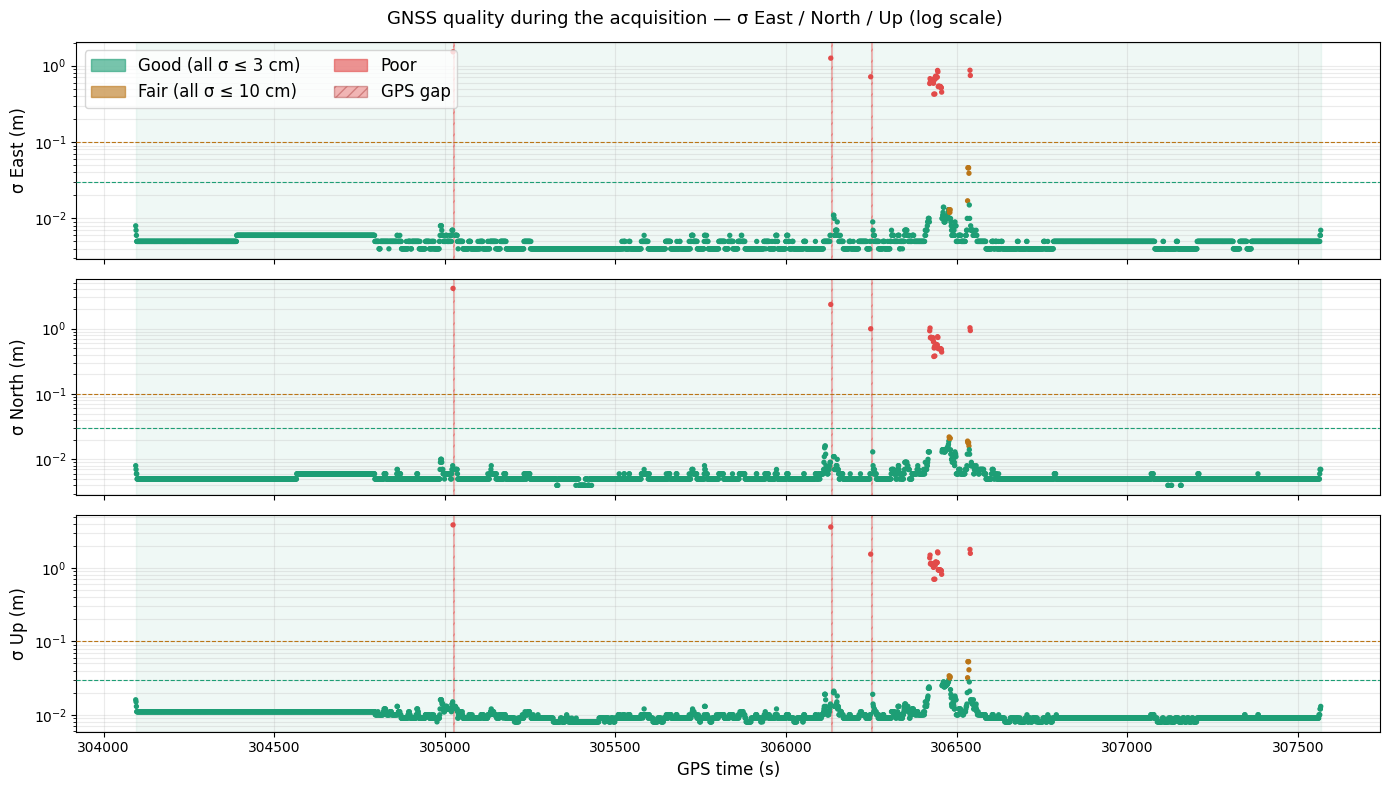


3 gap(s) detected — nominal rate: 1.0 s
  #1  305024.0 → 305030.0   Δt = 6.0 s  (00h00m06s)
  #2  306131.0 → 306139.0   Δt = 8.0 s  (00h00m08s)
  #3  306248.0 → 306254.0   Δt = 6.0 s  (00h00m06s)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Chargement ────────────────────────────────────────────────────────────
df = pd.read_csv(
    "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/base/in/GPS.txt",
    header=None,
    names=["time", "lat", "lon", "alt", "sig_E", "sig_N", "sig_H"]
)
df = df.sort_values("time").reset_index(drop=True)

# ── Quality thresholds (same for E / N / H) ──────────────────────────────
THR_GOOD = 0.03   # 3 cm
THR_WARN = 0.10   # 10 cm

# ── Quality flag per epoch ────────────────────────────────────────────────
def quality(row):
    vals = [row.sig_E, row.sig_N, row.sig_H]
    if all(v <= THR_GOOD for v in vals):
        return "good"
    elif all(v <= THR_WARN for v in vals):
        return "warn"
    return "bad"

df["quality"] = df.apply(quality, axis=1)

# ── Continuous segments + gaps ────────────────────────────────────────────
dt = df["time"].diff()
nominal_dt = dt.mode()[0]
threshold = dt.mode()[0] * 1.5
df["seg_id"] = (dt > threshold).cumsum()

segments, gaps = [], []
for sid, grp in df.groupby("seg_id"):
    dominant = grp["quality"].mode()[0]
    segments.append({
        "seg": sid + 1,
        "t_start": grp["time"].iloc[0],
        "t_end": grp["time"].iloc[-1],
        "duration": grp["time"].iloc[-1] - grp["time"].iloc[0],
        "n_epochs": len(grp),
        "quality": dominant,
        "sig_E_mean": grp["sig_E"].mean(),
        "sig_N_mean": grp["sig_N"].mean(),
        "sig_H_mean": grp["sig_H"].mean(),
    })

gap_idx = df.index[dt > threshold]
for i in gap_idx:
    gaps.append({
        "t_start": df["time"].iloc[i - 1],
        "t_end": df["time"].iloc[i],
        "dur": df["time"].iloc[i] - df["time"].iloc[i - 1],
    })

seg_df = pd.DataFrame(segments)
gap_df = pd.DataFrame(gaps) if gaps else pd.DataFrame(columns=["t_start", "t_end", "dur"])

# ── Plot ──────────────────────────────────────────────────────────────────
color_map = {"good": "#1D9E75", "warn": "#BA7517", "bad": "#E24B4A"}
cols = ["sig_E", "sig_N", "sig_H"]
labels = ["σ East (m)", "σ North (m)", "σ Up (m)"]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.suptitle("GNSS quality during the acquisition — σ East / North / Up (log scale)", fontsize=13)

for ax, col, label in zip(axes, cols, labels):
    for _, s in seg_df.iterrows():
        ax.axvspan(
            s.t_start, s.t_end,
            alpha=0.07, color=color_map[s.quality], zorder=1
        )

    for _, g in gap_df.iterrows():
        ax.axvspan(
            g.t_start, g.t_end,
            alpha=0.40, color="#E24B4A", hatch="///",
            edgecolor="#A32D2D", linewidth=0, zorder=2
        )

    colors = [color_map[q] for q in df["quality"]]
    ax.scatter(df["time"], df[col], c=colors, s=8, zorder=4)

    ax.axhline(THR_GOOD, color="#1D9E75", lw=0.8, ls="--", zorder=3)
    ax.axhline(THR_WARN, color="#BA7517", lw=0.8, ls="--", zorder=3)

    ax.set_yscale("log")   
    ax.set_ylabel(label, fontsize=12)
    ax.grid(True, which="both", alpha=0.25)
    ax.tick_params(axis='both', labelsize=10)

axes[-1].set_xlabel("GPS time (s)", fontsize=12)
#axes[-1].tick_params(axis='x', labelsize=10)

patches = [
    mpatches.Patch(
        color="#1D9E75", alpha=0.6,
        label=f"Good (all σ ≤ {THR_GOOD*100:.0f} cm)"
    ),
    mpatches.Patch(
        color="#BA7517", alpha=0.6,
        label=f"Fair (all σ ≤ {THR_WARN*100:.0f} cm)"
    ),
    mpatches.Patch(color="#E24B4A", alpha=0.6, label="Poor"),
    mpatches.Patch(
        facecolor="#E24B4A", alpha=0.4, hatch="///",
        edgecolor="#A32D2D", label="GPS gap"
    ),
]
axes[0].legend(handles=patches, fontsize=12, loc="upper left", ncol=2)

plt.tight_layout()
plt.savefig("/home/b085164/PDM_Romain_Defferrard/images/gps_quality_CALIB.png", dpi=400, bbox_inches="tight")
plt.show()

# ── Gap summary ───────────────────────────────────────────────────────────
print(f"\n{len(gap_df)} gap(s) detected — nominal rate: {nominal_dt:.1f} s")
for i, (_, g) in enumerate(gap_df.iterrows(), 1):
    h, m, s = int(g.dur)//3600, (int(g.dur)%3600)//60, int(g.dur)%60
    print(f"  #{i}  {g.t_start:.1f} → {g.t_end:.1f}   Δt = {g.dur:.1f} s  ({h:02d}h{m:02d}m{s:02d}s)")

/tmp/ipykernel_313212/4293906530.py:72: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(g.t_start, g.t_end,


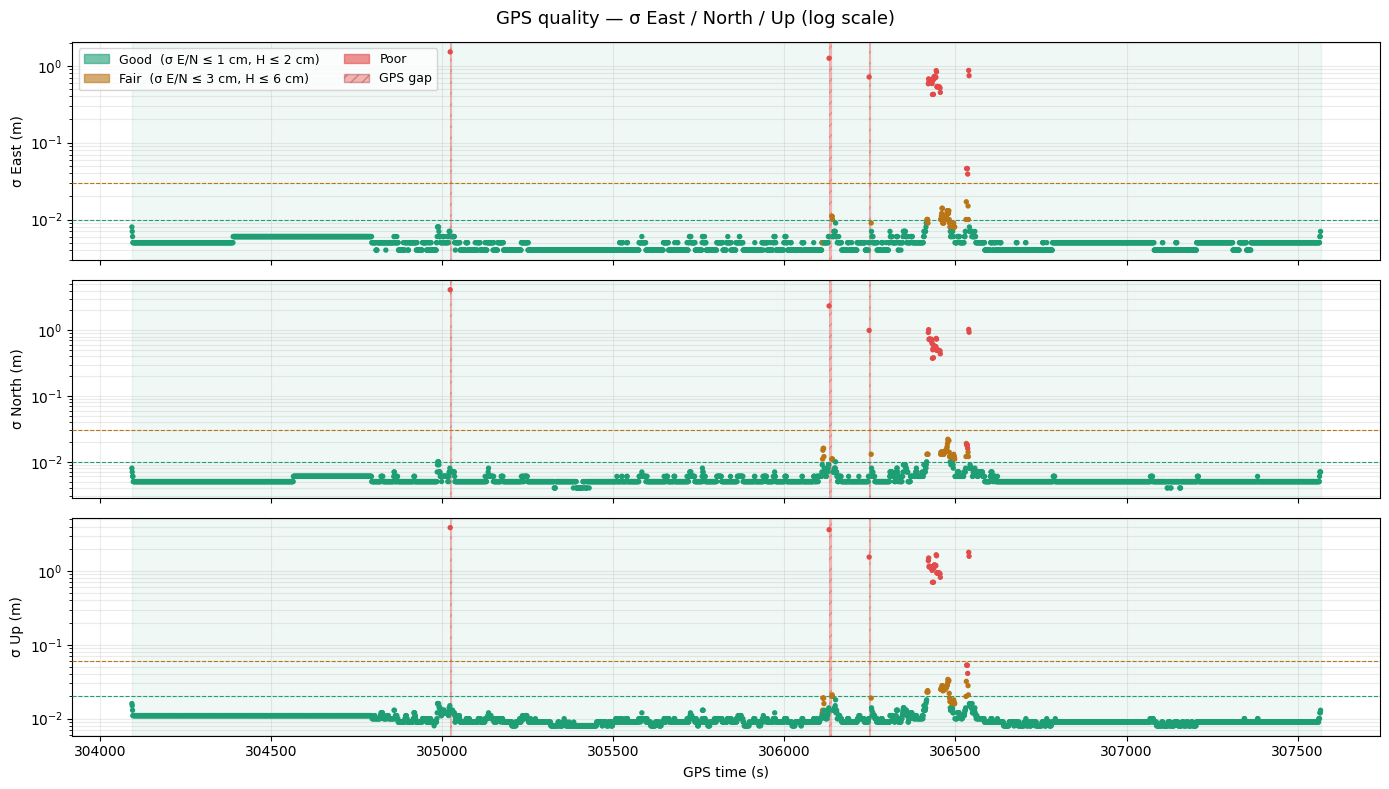


3 gap(s) detected — nominal rate: 1.0 s
  #1  305024.0 → 305030.0   Δt = 6.0 s  (00h00m06s)
  #2  306131.0 → 306139.0   Δt = 8.0 s  (00h00m08s)
  #3  306248.0 → 306254.0   Δt = 6.0 s  (00h00m06s)


: 

## Merge et classif des trois scanner

### Fait:

- lit les nuages VUX déjà merged d'un dossier
- lit les nuages PUCK d'un autre dossier 
- utilise les `gps_time` pour répartir les points puck dans le bon nuages VUX
- Règle spéciale: les point du PUCK entre deux nuages VUX vont dans le nuage suivant 
- Ajoute un extrabyte `scanner_src`:
    - 2 = point venant des VUX
    - 1 = point venant du PUCK

## Fichier LiDAR_p2p problématique 


In [ ]:
import os
import random

input_file = "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/Outage_1_305120_305700/S2S/in/chunks/full/LiDAR_p2p.txt"

k = 540000
output_dir = f"/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/Outage_1_305120_305700/S2S/in/chunks/full/random_{k}"
output_file = os.path.join(output_dir, "LiDAR_p2p.txt")

# --- Create directory ---
os.makedirs(output_dir, exist_ok=True)

# --- Optional: fix seed pour reproductibilité ---
random.seed(42)

reservoir = []

# --- Sampling ---
with open(input_file, "r") as f:
    for i, line in enumerate(f):
        if i < k:
            reservoir.append(line)
        else:
            j = random.randint(0, i)
            if j < k:
                reservoir[j] = line

print(f"Sampling terminé : {len(reservoir)} lignes")

# --- Sort sur la première colonne ---
def get_first_col(line):
    return float(line.split()[0].rstrip(","))

reservoir.sort(key=get_first_col)

# --- Write ---
with open(output_file, "w") as f:
    f.writelines(reservoir)

print(f"Fichier écrit dans : {output_file}")

Sampling terminé : 540000 lignes
Fichier écrit dans : /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/Outage_1_305120_305700/S2S/in/chunks/full/random_540000/LiDAR_p2p.txt


## Success rate des méthodes

In [ ]:
import os

# =========================
# CONFIG
# =========================

limatch_paths = [
    # "/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/limatch_F2B_v2",
    # "/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/limatch_F2B_v2_crossings",
    # "/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/limatch_F2B_v2",
    # "/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/limatch_F2B_v2_crossings",
    # "/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_1/limatch_500x500",
    # "/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_1/limatch_crossings",
    "/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/APX/limatch_F2B", 
    "/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/APX/limatch_F2B", 
]

s2s_paths = [
    # # outage 1
    # "/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_1/s2s_chunks/pairs_1/Flights_1_2/Patch_from_scan_1_with_2_vs_Patch_from_scan_2_with_1/limatch",
    
    # # outage 2
    # "/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/s2s_chunks/limatch",
    
    # # outage 3
    # "/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/s2s_chunks",
]

# =========================
# UTILS
# =========================

def is_non_empty_dir(path):
    for f in os.listdir(path):
        full = os.path.join(path, f)
        if os.path.isfile(full) and os.path.getsize(full) > 0:
            return True
    return False

# =========================
# LIMATCH (merged/chunks)
# =========================

def compute_limatch_sr(base_dir):
    total, success = 0, 0

    for merged in os.listdir(base_dir):
        merged_path = os.path.join(base_dir, merged)
        if not os.path.isdir(merged_path):
            continue

        for chunk in os.listdir(merged_path):
            chunk_path = os.path.join(merged_path, chunk)
            cor_path = os.path.join(chunk_path, "cor_outputs")

            if not os.path.isdir(cor_path):
                continue

            total += 1
            if is_non_empty_dir(cor_path):
                success += 1

    return success, total

# =========================
# S2S (chunk direct)
# =========================

def compute_s2s_sr_nested(base_dir):
    total, success = 0, 0

    for root, dirs, files in os.walk(base_dir):
        # On cherche directement les dossiers "cor_outputs"
        if os.path.basename(root) == "cor_outputs":
            
            total += 1

            if is_non_empty_dir(root):
                success += 1

    return success, total

# =========================
# RUN
# =========================

print("===== LIMATCH =====")
limatch_total = 0
limatch_success = 0

for path in limatch_paths:
    s, t = compute_limatch_sr(path)
    limatch_total += t
    limatch_success += s
    print(f"{path} -> {s}/{t} ({s/t if t>0 else 0:.3f})")

print("\nGLOBAL LIMATCH SR :", limatch_success, "/", limatch_total, "->", 
      f"{limatch_success/limatch_total:.4f}" if limatch_total>0 else "N/A")


print("\n===== S2S =====")
s2s_total = 0
s2s_success = 0

for path in s2s_paths:
    s, t = compute_s2s_sr_nested(path)
    s2s_total += t
    s2s_success += s
    print(f"{path} -> {s}/{t} ({s/t if t>0 else 0:.3f})")

print("\nGLOBAL S2S SR :", s2s_success, "/", s2s_total, "->", 
      f"{s2s_success/s2s_total:.4f}" if s2s_total>0 else "N/A")

===== LIMATCH =====
/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/APX/limatch_F2B -> 135/270 (0.500)
/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/APX/limatch_F2B -> 80/259 (0.309)

GLOBAL LIMATCH SR : 215 / 529 -> 0.4064

===== S2S =====

GLOBAL S2S SR : 0 / 0 -> N/A


In [ ]:
import laspy as lp
las = lp.read("/media/b085164/LaCie/2026spring_RD/ECCR/georef_ALL_zone_3_outage/merged/ALL/merged_1000_VUX_PUCK.las")
print(f"header min gps_time : {las.header.mins}")
print(f"header max gps_time : {las.header.maxs}")
print(f"réel min gps_time   : {las.gps_time.min():.3f}")
print(f"réel max gps_time   : {las.gps_time.max():.3f}")

header min gps_time : [2.53315411e+06 1.15506819e+06 4.57270000e+02]
header max gps_time : [2.53331459e+06 1.15518327e+06 4.83854000e+02]
réel min gps_time   : 315632.000
réel max gps_time   : 315662.282


In [ ]:

from pathlib import Path
import numpy as np
import pandas as pd
import folium

# ------------------------------------------------------------
# INPUT
# ------------------------------------------------------------
manifest_path = "/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/APX/georef_F2B/merged/ALL/merged_manifest.csv"
traj_path     = "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/combined_w_traj_f2b/combined/in/reference.out"

output_html = Path("/home/b085164/PDM_Romain_Defferrard/ESO-PDM/traj_scanline.html")

t_start = None
t_end   = None
max_display_points = 5000

# ------------------------------------------------------------
# SBET dtype
# ------------------------------------------------------------
SBET_DTYPE = np.dtype([
    ("time",    np.float64), ("lat",  np.float64), ("lon",   np.float64),
    ("alt",     np.float64), ("vx",   np.float64), ("vy",    np.float64),
    ("vz",      np.float64), ("roll", np.float64), ("pitch", np.float64),
    ("heading", np.float64), ("wander",np.float64),("ax",    np.float64),
    ("ay",      np.float64), ("az",   np.float64), ("wx",    np.float64),
    ("wy",      np.float64), ("wz",   np.float64),
])

def load_sbet(path):
    return pd.DataFrame(np.fromfile(path, dtype=SBET_DTYPE))

def filter_time_window(df, t0, t1):
    mask = np.ones(len(df), dtype=bool)
    if t0 is not None: mask &= df["time"].to_numpy() >= t0
    if t1 is not None: mask &= df["time"].to_numpy() <= t1
    return df.loc[mask].copy()

def decimate_idx(n, max_n):
    if n <= max_n:
        return np.arange(n)
    return np.linspace(0, n-1, max_n).astype(int)

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
traj = filter_time_window(load_sbet(traj_path), t_start, t_end)
manifest = pd.read_csv(manifest_path)

# ------------------------------------------------------------
# MERGE ON TIME
# ------------------------------------------------------------
# ------------------------------------------------------------
# PREP MANIFEST
# ------------------------------------------------------------
manifest = manifest.sort_values("t_start").reset_index(drop=True)

t_start = manifest["t_start"].to_numpy()
t_end   = manifest["t_end"].to_numpy()
scan_id = manifest["scan_id"].to_numpy()

# ------------------------------------------------------------
# ASSIGN SCAN ID TO TRAJ
# ------------------------------------------------------------
t = traj["time"].to_numpy()

# trouve l'intervalle candidat
idx = np.searchsorted(t_start, t, side="right") - 1

# filtre valide (dans intervalle)
valid = (idx >= 0) & (t <= t_end[idx])

scan = np.full(len(t), -1, dtype=np.int32)
scan[valid] = scan_id[idx[valid]]

# ajoute au dataframe
traj["scan_id"] = scan

# garde seulement les points valides
df = traj[traj["scan_id"] >= 0].copy()

print("Points assignés à un scan:", len(df))

# ------------------------------------------------------------
# FIND SCAN LINE COLUMN
# ------------------------------------------------------------
scan_col = [c for c in df.columns if "scan" in c.lower()][0]
print("Scan column:", scan_col)

# ------------------------------------------------------------
# DECIMATE
# ------------------------------------------------------------
idx = decimate_idx(len(df), max_display_points)

lat = np.degrees(df["lat"].to_numpy()[idx])
lon = np.degrees(df["lon"].to_numpy()[idx])
scan = df[scan_col].to_numpy()[idx]
time = df["time"].to_numpy()[idx]

# ------------------------------------------------------------
# COLOR MAPPING
# ------------------------------------------------------------
# normalisation (robuste)
scan_norm = (scan - scan.min()) / (scan.max() - scan.min() + 1e-9)

# ------------------------------------------------------------
# COLOR MAP (DISCRETE)
# ------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

unique_scans = np.unique(scan)
n_scans = len(unique_scans)

# palette qualitative
cmap = plt.get_cmap("tab20", min(n_scans, 20))

scan_to_color = {}
for i, s in enumerate(unique_scans):
    color = mcolors.to_hex(cmap(i % 20))
    scan_to_color[s] = color

# ------------------------------------------------------------
# MAP
# ------------------------------------------------------------
center = [lat.mean(), lon.mean()]
m = folium.Map(
    location=center,
    zoom_start=14,
    max_zoom=22,
    tiles="https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png",
    attr="CartoDB"
)

# ------------------------------------------------------------
# DRAW TRAJ (by scan)
# ------------------------------------------------------------
for i in range(len(lat) - 1):
    s = scan[i]
    if s < 0:
        continue

    color = scan_to_color[s]

    folium.PolyLine(
        locations=[(lat[i], lon[i]), (lat[i+1], lon[i+1])],
        color=color,
        weight=3,
        opacity=0.9,
        tooltip=f"scan={s} | t={time[i]:.3f}"
    ).add_to(m)

# ------------------------------------------------------------
# LEGEND (LIMITED)
# ------------------------------------------------------------
MAX_LEGEND = 15  # évite une légende énorme

legend_items = list(scan_to_color.items())[:MAX_LEGEND]

legend_html = """
<div style="
position: fixed;
top: 30px;
right: 30px;
z-index: 1000;
background: white;
padding: 10px;
border-radius: 6px;
box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
font-size: 13px;
">
<b>Scan lines</b><br>
"""

for s, c in legend_items:
    legend_html += f'<span style="color:{c};">&#9632;</span> scan {s}<br>'

if n_scans > MAX_LEGEND:
    legend_html += "<i>... others</i><br>"

legend_html += "</div>"

m.get_root().html.add_child(folium.Element(legend_html))

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
m.save(str(output_html))
print(f"Saved: {output_html}")

Points assignés à un scan: 10700
Scan column: scan_id
Saved: /home/b085164/PDM_Romain_Defferrard/ESO-PDM/traj_scanline.html


In [ ]:
print(manifest.columns)

Index(['scan_id', 'filename', 't_start', 't_end'], dtype='object')


In [ ]:
# ==============================================================
# CELL 1 — CONFIG
# ==============================================================
import numpy as np
import laspy
import pandas as pd
from pathlib import Path
import sys
sys.path.insert(0, "/home/b085164/PDM_Romain_Defferrard/ESO-PDM")

BASE_DIR = Path("/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/APX/georef_F2B/merged/ALL")
OUT_BASE = Path("/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/APX/georef_F2B/crop_v2")
OUT_BASE.mkdir(parents=True, exist_ok=True)

LIMATCH_CFG = "/home/b085164/PDM_Romain_Defferrard/ESO-PDM/Patcher/submodules/limatch/configs/MLS_F2B_1_APX.yml"


PAIRS = [
    ( 9000, (305812, 305824), 10000, (305849, 305858)),   # 0 DONE [4, 6.5]
    (19000, (306101, 306105),  1000, (305695, 305703)),   # 1 DONE [2, 3] lcd 1 rsc 0.5
    (18000, (305954, 305960), 19000, (306090, 306096)),   # 2 DONE [20, 21]
    (18000, (305975, 305985), 19000, (306068, 306077)),   # 3 DONE [17.5, 19]
    (18000, (306004, 306022), 19000, (306027, 306050)),   # 4  [11, 12.5] lcp 2, augmenter kpts
    ( 2000, (305724, 305733), 13000, (305904, 305910)),   # 5 DONE [15, 16.5]
    ( 2000, (305724, 305733),  9000, (305796, 305805)),   # 6 DONE [9.5, 11.5]
    ( 4000, (305744, 305754),  7000, (305776, 305785)),   # 7 DONE []
    ( 4000, (305744, 305754), 11000, (305886, 305891)),   # 8 DONE [11, 13]
    ( 4000, (305744, 305754), 15000, (305920, 305927)),   # 9 DONE [10, 12]
    (11000, (305886, 305891), 15000, (305920, 305927)),   # 10 [0, 2]
    ( 4000, (305755, 305763),  2000, (305706, 305723)),   # 11 [5, 7]
    ( 4000, (305745, 305752), 18000, (305955, 305962)),   # 12 [9, 11]
    (18000, (305953, 305958), 19000, (306094, 306098)),   # 13 PAS A FAIRE []
    (17000, (305939, 305947),  2000, (305721, 305729)),   # 14 DONE [13, 14.5]
    (16000, (305932, 305944),  9000, (305800, 305810)),   # 15
    (18000, (305953, 305960), 7000, (305775, 305785)),   # 16 
]

print(f"{len(PAIRS)} paires configurées")
for i, (sa, ta, sb, tb) in enumerate(PAIRS):
    print(f"  [{i:2d}] merged_{sa} [{ta[0]}-{ta[1]}] ↔ merged_{sb} [{tb[0]}-{tb[1]}]")

17 paires configurées
  [ 0] merged_9000 [305812-305824] ↔ merged_10000 [305849-305858]
  [ 1] merged_19000 [306101-306105] ↔ merged_1000 [305695-305703]
  [ 2] merged_18000 [305954-305960] ↔ merged_19000 [306090-306096]
  [ 3] merged_18000 [305975-305985] ↔ merged_19000 [306068-306077]
  [ 4] merged_18000 [306004-306022] ↔ merged_19000 [306027-306050]
  [ 5] merged_2000 [305724-305733] ↔ merged_13000 [305904-305910]
  [ 6] merged_2000 [305724-305733] ↔ merged_9000 [305796-305805]
  [ 7] merged_4000 [305744-305754] ↔ merged_7000 [305776-305785]
  [ 8] merged_4000 [305744-305754] ↔ merged_11000 [305886-305891]
  [ 9] merged_4000 [305744-305754] ↔ merged_15000 [305920-305927]
  [10] merged_11000 [305886-305891] ↔ merged_15000 [305920-305927]
  [11] merged_4000 [305755-305763] ↔ merged_2000 [305706-305723]
  [12] merged_4000 [305745-305752] ↔ merged_18000 [305955-305962]
  [13] merged_18000 [305953-305958] ↔ merged_19000 [306094-306098]
  [14] merged_17000 [305939-305947] ↔ merged_2000 [3

In [ ]:
# ==============================================================
# CELL 2 — CROP optimisé (une lecture par fichier source)
# ==============================================================
from collections import defaultdict

def crop_las_by_time_fast(las_path, crops):
    """
    crops : list de (t0, t1, out_path)
    Lit le fichier une seule fois et écrit tous les crops.
    """
    # Filtre les crops déjà faits
    todo = [(t0, t1, p) for t0, t1, p in crops if not p.exists()]
    done = [(t0, t1, p) for t0, t1, p in crops if p.exists()]

    for _, _, p in done:
        print(f"    [SKIP] {p.name}")

    if not todo:
        return

    print(f"    Lecture {las_path.name}...", end=" ", flush=True)
    las = laspy.read(las_path)
    t   = np.asarray(las.gps_time)
    print(f"{len(t):,} pts")

    for t0, t1, out_path in todo:
        mask   = (t >= t0) & (t <= t1)
        n_kept = int(mask.sum())
        print(f"    [{t0}-{t1}] → {n_kept:,} pts", end=" ")
        if n_kept == 0:
            print("!! vide")
            continue
        las[mask].write(out_path)
        print(f"→ {out_path.name}")

# Groupe les crops par fichier source
file_to_crops = defaultdict(list)  # {las_path: [(t0, t1, out_path, pair_idx, role)]}

for i, (sid_a, t_crop_a, sid_b, t_crop_b) in enumerate(PAIRS):
    out_dir = OUT_BASE / f"pair_{i:02d}_{sid_a}_{sid_b}"
    out_dir.mkdir(parents=True, exist_ok=True)
    file_to_crops[BASE_DIR / f"merged_{sid_a}_VUX_PUCK.las"].append(
        (*t_crop_a, out_dir / f"scan_{sid_a}_crop.las"))
    file_to_crops[BASE_DIR / f"merged_{sid_b}_VUX_PUCK.las"].append(
        (*t_crop_b, out_dir / f"scan_{sid_b}_crop.las"))

# Une seule lecture par fichier source
for las_path, crops in sorted(file_to_crops.items()):
    print(f"\n  {las_path.name}  ({len(crops)} crops)")
    crop_las_by_time_fast(las_path, crops)

# Reconstruit crop_paths
crop_paths = {}
for i, (sid_a, t_crop_a, sid_b, t_crop_b) in enumerate(PAIRS):
    out_dir = OUT_BASE / f"pair_{i:02d}_{sid_a}_{sid_b}"
    path_a  = out_dir / f"scan_{sid_a}_crop.las"
    path_b  = out_dir / f"scan_{sid_b}_crop.las"
    crop_paths[i] = (
        out_dir,
        path_a if path_a.exists() else None,
        path_b if path_b.exists() else None,
    )

n_ok = sum(1 for v in crop_paths.values() if v[1] and v[2])
print(f"\n{n_ok}/{len(PAIRS)} paires prêtes.")


  merged_10000_VUX_PUCK.las  (1 crops)
    [SKIP] scan_10000_crop.las

  merged_1000_VUX_PUCK.las  (1 crops)
    [SKIP] scan_1000_crop.las

  merged_11000_VUX_PUCK.las  (2 crops)
    [SKIP] scan_11000_crop.las
    [SKIP] scan_11000_crop.las

  merged_13000_VUX_PUCK.las  (1 crops)
    [SKIP] scan_13000_crop.las

  merged_15000_VUX_PUCK.las  (2 crops)
    [SKIP] scan_15000_crop.las
    [SKIP] scan_15000_crop.las

  merged_16000_VUX_PUCK.las  (1 crops)
    [SKIP] scan_16000_crop.las

  merged_17000_VUX_PUCK.las  (1 crops)
    [SKIP] scan_17000_crop.las

  merged_18000_VUX_PUCK.las  (6 crops)
    [SKIP] scan_18000_crop.las
    [SKIP] scan_18000_crop.las
    [SKIP] scan_18000_crop.las
    [SKIP] scan_18000_crop.las
    [SKIP] scan_18000_crop.las
    Lecture merged_18000_VUX_PUCK.las... 76,557,827 pts
    [305953-305960] → 6,860,492 pts → scan_18000_crop.las

  merged_19000_VUX_PUCK.las  (5 crops)
    [SKIP] scan_19000_crop.las
    [SKIP] scan_19000_crop.las
    [SKIP] scan_19000_crop.las
 

[09:06:14] INFO | Starting LiMatch pipeline...
[09:06:14] INFO |   └─ Will save data at: /media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/APX/georef_F2B/crop_v2/pair_16_18000_7000/limatch/
[09:06:14] INFO | Visualization set to False
[09:06:14] INFO | [0/7] Model setup
[09:06:14] INFO |   └─ Using CUDA for descriptor inference.
[09:06:14] INFO |   └─ Loading from: /home/b085164/PDM_Romain_Defferrard/ESO-PDM/Patcher/submodules/limatch/weights/model.pth
[09:06:14] INFO |   └─ Loaded nested checkpoint with key 'model'.
[09:06:14] INFO |   └─ Descriptor model successfully loaded and set to eval() mode.
[09:06:14] INFO | [1/7] Preprocessing
[09:06:14] INFO |   └─ Loading point clouds...


11 paires avec corres existants sur disque
Paires à lancer : [16]


[16] LiMatch — scan_18000_crop.las / scan_7000_crop.las
[limatch-api] prj_folder=/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/APX/georef_F2B/crop_v2/pair_16_18000_7000/limatch/


[09:06:14] INFO |   └─ Loaded laser vectors from LAS extra bytes: /media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/APX/georef_F2B/crop_v2/pair_16_18000_7000/scan_18000_crop.las
[09:06:15] INFO |   └─ Loaded laser vectors from LAS extra bytes: /media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/APX/georef_F2B/crop_v2/pair_16_18000_7000/scan_7000_crop.las
[09:06:17] INFO |   └─ No tiling... (all points kept)
[09:06:17] INFO |   └─ Shifting point clouds toward origin...
[09:06:17] INFO |       └─ [2542665.7  1157344.93     905.1 ] m...
[09:06:17] INFO |       └─ (Coordinates shifted back at export)
[09:06:20] INFO |   └─ Generated 1 valid tiles.
[09:06:20] INFO |   └─ Applying voxelization with size 0.025 m...
[09:06:23] INFO |       └─ voxelized from 6860492 to 2838307 pts (41.37%)
[09:06:29] INFO |       └─ voxelized from 9713552 to 3659670 pts (37.68%)
[09:06:30] INFO | [2/7] Keypoint detection
[09:06:37] INFO |   └─ Deleting kpts without candidate in radius 

  → corres_scan_18000_crop_scan_7000_crop.txt

12/17 paires avec correspondances.


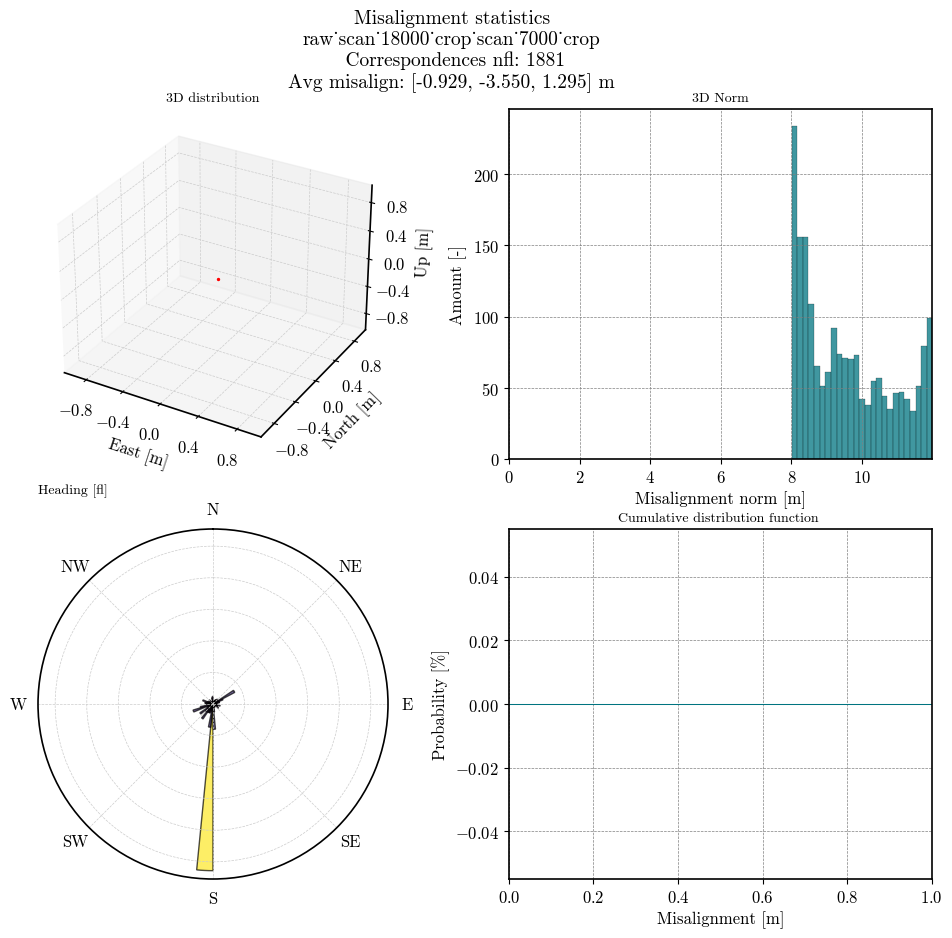

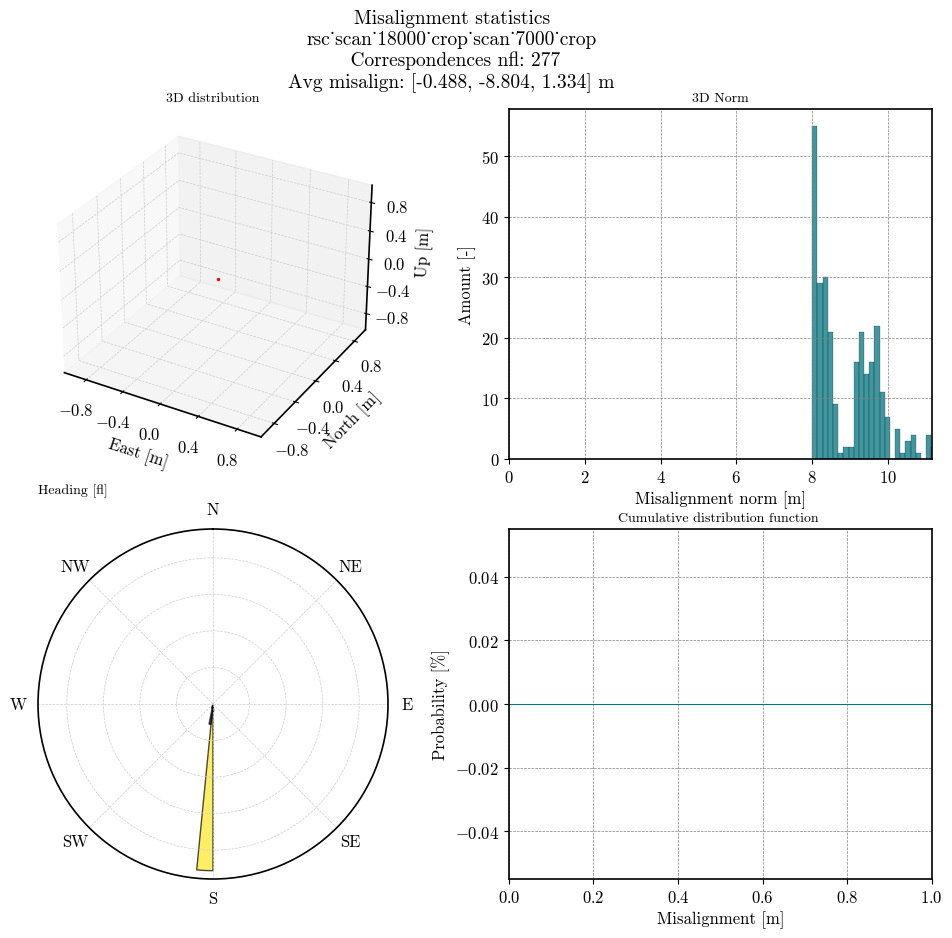

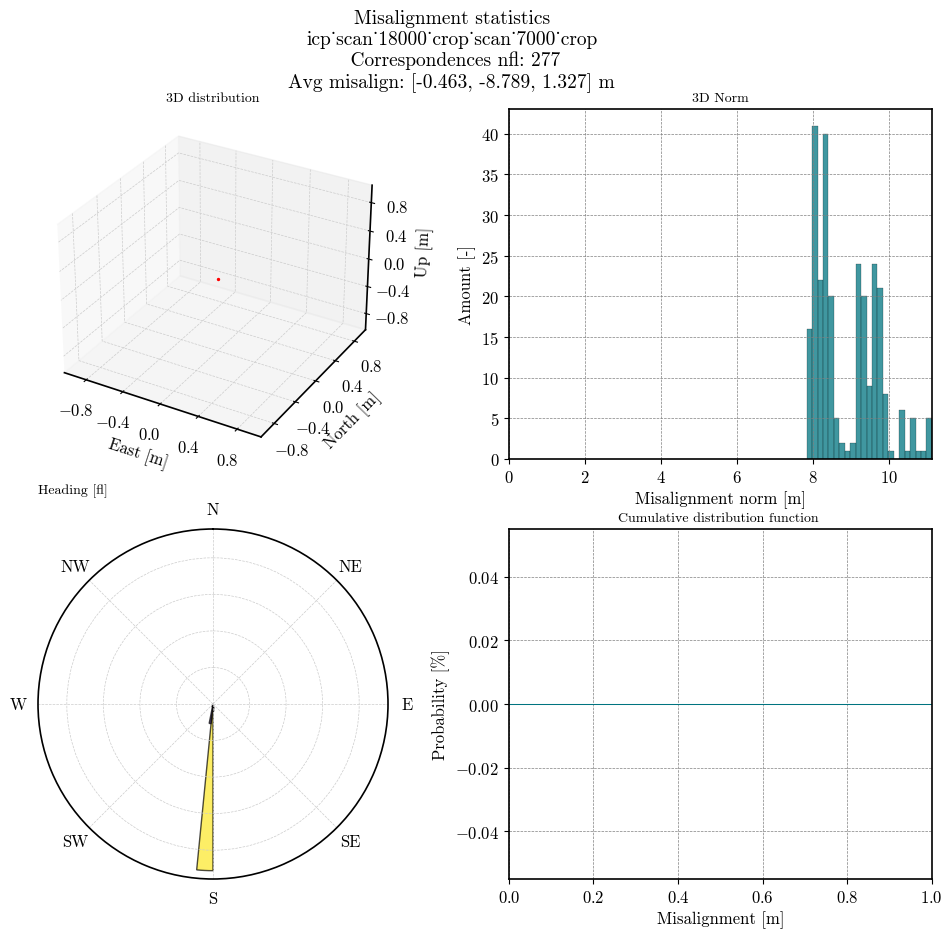

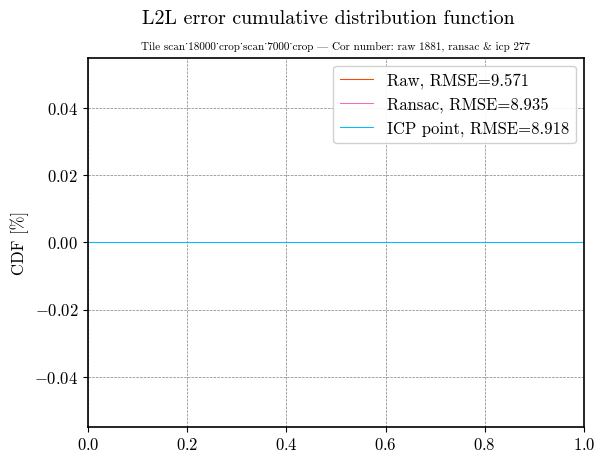

In [ ]:
# ==============================================================
# CELL 3 — LANCER LIMATCH (sélection par index)
# ==============================================================
from navtools_PDM.pipeline import run_limatch_api, get_repo_root

repo_root = get_repo_root()

# ← Modifie cette liste pour choisir les paires à lancer
PAIRS_TO_RUN = [16]   # indices dans PAIRS

limatch_results = {}  # {pair_idx: (out_dir, corres_path)}

# Charge d'abord les résultats existants sur disque
for i in range(len(PAIRS)):
    out_dir = crop_paths[i][0]
    lm_dir  = out_dir / "limatch"
    existing = list(lm_dir.rglob("corres_*.txt"))
    if existing:
        limatch_results[i] = (out_dir, existing[0])

print(f"{len(limatch_results)} paires avec corres existants sur disque")
print(f"Paires à lancer : {PAIRS_TO_RUN}\n")

for i in PAIRS_TO_RUN:
    out_dir, path_a, path_b = crop_paths[i]
    lm_dir = out_dir / "limatch"

    if i in limatch_results:
        print(f"[{i:2d}] SKIP — {limatch_results[i][1].name}")
        continue

    if path_a is None or path_b is None:
        print(f"[{i:2d}] SKIP — crop vide")
        continue

    print(f"\n[{i:2d}] LiMatch — {path_a.name} / {path_b.name}")
    run_limatch_api(
        repo_root=repo_root,
        limatch_cfg_path=LIMATCH_CFG,
        cloud1=path_a,
        cloud2=path_b,
        out_dir=lm_dir,
    )

    corres_files = list(lm_dir.rglob("corres_*.txt"))
    if corres_files:
        limatch_results[i] = (out_dir, corres_files[0])
        print(f"  → {corres_files[0].name}")
    else:
        print(f"  !! Pas de corres_*.txt")

print(f"\n{len(limatch_results)}/{len(PAIRS)} paires avec correspondances.")

# L2L distance Discussion

Scenario                         N   Q50 [mm]   Q75 [mm]   Q90 [mm]   Q95 [mm]  Mean [mm]
------------------------------------------------------------------------------------------
  Outage 1 — AIRINS         163252      31.00      41.00      60.00      98.00      37.83
  Outage 2 — AIRINS         156443      33.00      53.00      92.00     191.00      49.90
  Outage 3 — AIRINS         342502      54.00     116.00     165.00     202.00      77.02
  Outage 1 — APX15           64887     736.00    1794.00    2537.00    4692.40    1239.90
  Outage 2 — APX15           39899     268.00     401.00     923.00    1258.00     393.85
  Outage 3 — APX15           29474     261.00     635.00    1127.00    1839.05     482.06


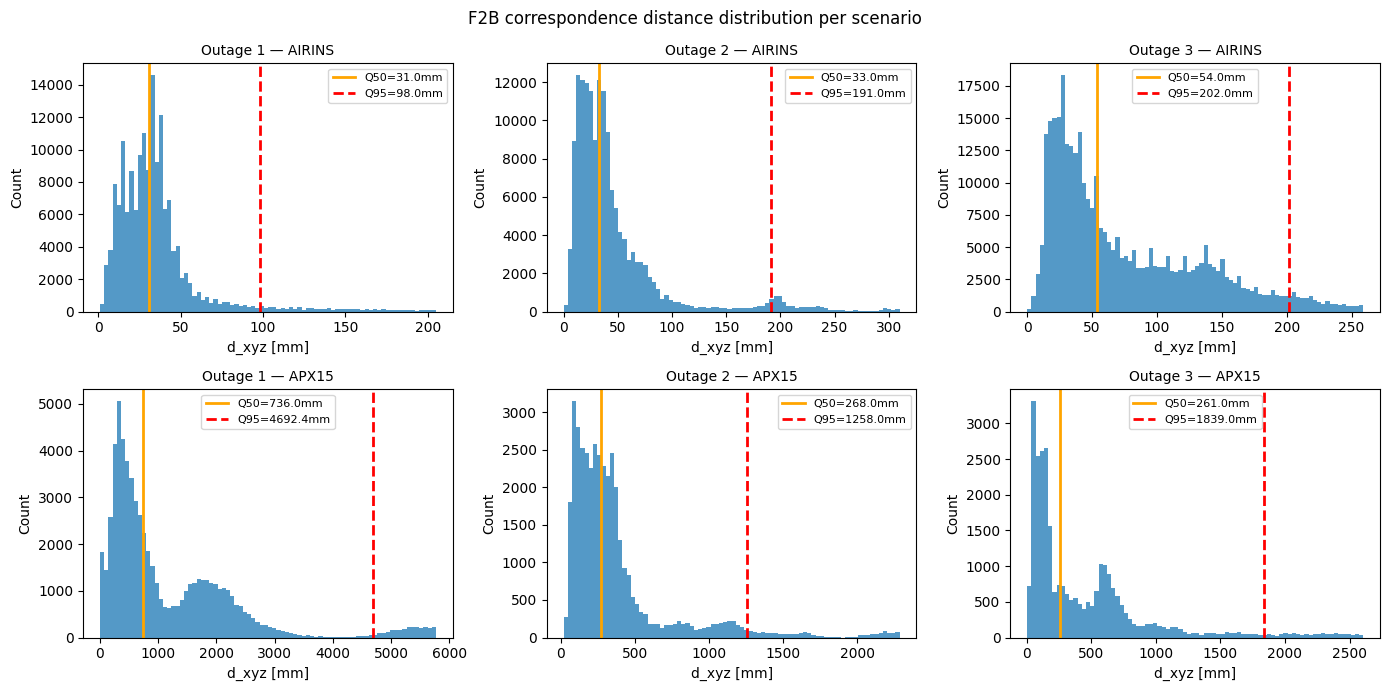

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# INPUTS
# ============================================================

SCENARIOS = {
    "Outage 1 — AIRINS": Path("/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_1/limatch_F2B_v3"),
    "Outage 2 — AIRINS": Path("/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/limatch_F2B_v2"),
    "Outage 3 — AIRINS": Path("/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/limatch_F2B_v2"),
    "Outage 1 — APX15":  Path("/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_1/APX/limatch_F2B"),
    "Outage 2 — APX15":  Path("/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/APX/limatch_F2B_v1"),
    "Outage 3 — APX15":  Path("/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/APX/limatch_F2B"),
}

CORRES_COLS = ["time_a","x_a","y_a","z_a",
               "time_b","x_b","y_b","z_b",
               "d_xyz","icp_x","icp_y","icp_z"]

# ============================================================
# CHARGEMENT
# ============================================================

def load_all_corres(root: Path) -> np.ndarray:
    """Charge tous les fichiers corres_*.txt sous root récursivement."""
    all_d = []
    files = list(root.rglob("corres_*.txt"))
    if not files:
        print(f"  WARNING: aucun fichier trouvé sous {root}")
        return np.array([])
    for f in files:
        try:
            df = pd.read_csv(f, header=None, names=CORRES_COLS,
                             sep=r",\s*", engine="python", skiprows=1)
            df = df.apply(pd.to_numeric, errors="coerce").dropna()
            if "d_xyz" in df.columns and len(df) > 0:
                all_d.append(df["d_xyz"].values)
        except Exception as e:
            print(f"  Skipping {f.name}: {e}")
    if not all_d:
        return np.array([])
    return np.concatenate(all_d) * 1000  # → mm

# ============================================================
# STATS
# ============================================================

results = {}

print(f"{'Scenario':<25} {'N':>8} {'Q50 [mm]':>10} {'Q75 [mm]':>10} "
      f"{'Q90 [mm]':>10} {'Q95 [mm]':>10} {'Mean [mm]':>10}")
print("-" * 90)

for label, root in SCENARIOS.items():
    d = load_all_corres(root)
    if len(d) == 0:
        print(f"  {label:<23} — no data")
        continue
    results[label] = d
    print(f"  {label:<23} {len(d):>8} "
          f"{np.percentile(d,50):>10.2f} "
          f"{np.percentile(d,75):>10.2f} "
          f"{np.percentile(d,90):>10.2f} "
          f"{np.percentile(d,95):>10.2f} "
          f"{np.mean(d):>10.2f}")

# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=False)
axes = axes.flatten()

for ax, (label, d) in zip(axes, results.items()):
    q50 = np.percentile(d, 50)
    q95 = np.percentile(d, 95)
    # Clip pour la lisibilité
    d_clip = d[d < np.percentile(d, 99)]
    ax.hist(d_clip, bins=80, color="#2980B9", edgecolor="none", alpha=0.8)
    ax.axvline(q50, color="orange", lw=2, label=f"Q50={q50:.1f}mm")
    ax.axvline(q95, color="red", lw=2, linestyle="--", label=f"Q95={q95:.1f}mm")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("d_xyz [mm]")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("F2B correspondence distance distribution per scenario", fontsize=12)
plt.tight_layout()
plt.show()

# Debug outage 2 apx

In [13]:
# Colle ça dans une cellule et montre-moi le output
import numpy as np
from pathlib import Path

P2P_A = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/F2B/in/LiDAR_p2p.txt")
P2P_B = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/F2B/in/v2/LiDAR_p2p.txt")

for p in [P2P_A, P2P_B]:
    with open(p) as f:
        lines = f.readlines()
    print(f"=== {p.name} ===")
    print(f"  {len(lines)} lignes")
    print(f"  header : {[l for l in lines[:5] if l.startswith('#')]}")
    print(f"  ligne 1 : {lines[0] if not lines[0].startswith('#') else lines[-1]}")
    print()

=== LiDAR_p2p.txt ===
  39899 lignes
  header : []
  ligne 1 : 305635.986268959, 305635.304456246, -18.5717, -15.3996, 0.3910, -8.2263, -15.3413, 0.636


=== LiDAR_p2p.txt ===
  50011 lignes
  header : []
  ligne 1 : 305838.579650694, 305836.758808704, -5.1003, 2.7245, -1.9309, 1.5029, 4.9898, -1.8193




In [14]:
# ── CELL 1 — Chargement ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

COLS = ['time_a', 'time_b', 'dx_a', 'dy_a', 'dz_a', 'dx_b', 'dy_b', 'dz_b']

P2P = {
    'Run 1': Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/F2B/in/LiDAR_p2p.txt"),
    'Run 2': Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/F2B/in/v2/LiDAR_p2p.txt"),
}

# Bornes temporelles de l'outage
T_OUTAGE_START = 305645.0
T_OUTAGE_END   = 306120.0

dfs = {}
for label, path in P2P.items():
    df = pd.read_csv(path, header=None, names=COLS)
    dfs[label] = df
    print(f"=== {label} ===")
    print(f"  {len(df):,} correspondances")
    print(f"  time_a : [{df.time_a.min():.1f}, {df.time_a.max():.1f}]")
    print(f"  time_b : [{df.time_b.min():.1f}, {df.time_b.max():.1f}]")
    print(f"  Δt = time_b - time_a : "
          f"min={( df.time_b - df.time_a).min():.1f}  "
          f"max={(df.time_b - df.time_a).max():.1f}  "
          f"median={(df.time_b - df.time_a).median():.1f} s")
    print()

=== Run 1 ===
  39,899 correspondances
  time_a : [305636.0, 306130.0]
  time_b : [305635.0, 306117.4]
  Δt = time_b - time_a : min=-14.0  max=-0.0  median=-1.2 s

=== Run 2 ===
  50,011 correspondances
  time_a : [305616.9, 306150.0]
  time_b : [305615.9, 306147.6]
  Δt = time_b - time_a : min=-14.7  max=-0.0  median=-1.3 s



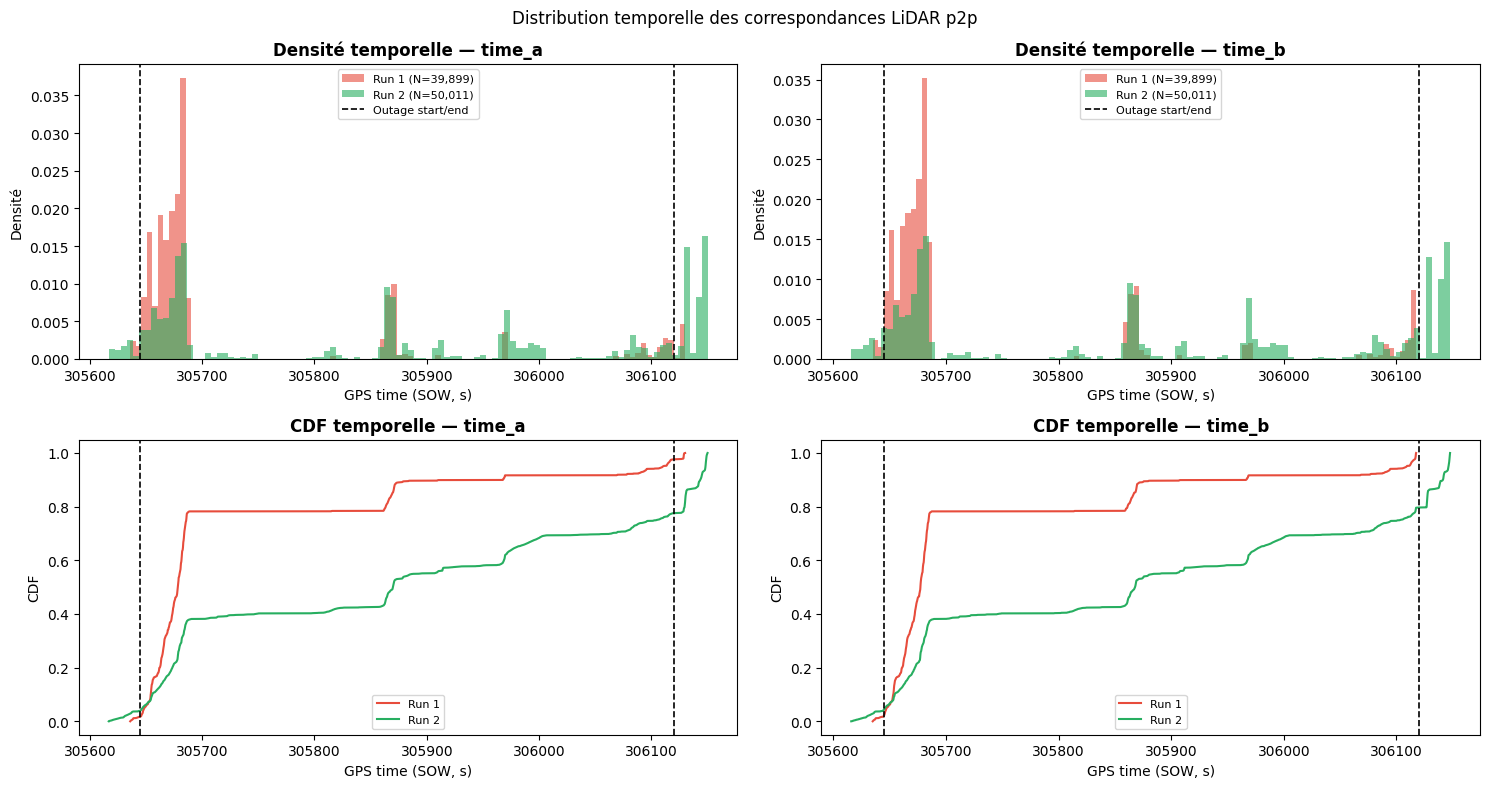

In [15]:
# ── CELL 2 — Distribution temporelle des correspondances ─────
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

COLORS = {'Run 1': '#e74c3c', 'Run 2': '#27ae60'}

for col_i, t_col in enumerate(['time_a', 'time_b']):
    ax_top = axes[0, col_i]
    ax_bot = axes[1, col_i]

    for label, df in dfs.items():
        color = COLORS[label]
        # Histogramme de densité temporelle
        ax_top.hist(df[t_col], bins=100, alpha=0.6, color=color,
                    label=f"{label} (N={len(df):,})", density=True)

    ax_top.axvline(T_OUTAGE_START, color='black', lw=1.2, ls='--', label='Outage start/end')
    ax_top.axvline(T_OUTAGE_END,   color='black', lw=1.2, ls='--')
    ax_top.set_title(f"Densité temporelle — {t_col}", fontweight='bold')
    ax_top.set_xlabel("GPS time (SOW, s)")
    ax_top.set_ylabel("Densité")
    ax_top.legend(fontsize=8)

    # Cumulatif
    for label, df in dfs.items():
        color = COLORS[label]
        t_sorted = np.sort(df[t_col].values)
        cdf = np.arange(1, len(t_sorted)+1) / len(t_sorted)
        ax_bot.plot(t_sorted, cdf, color=color, lw=1.5, label=label)

    ax_bot.axvline(T_OUTAGE_START, color='black', lw=1.2, ls='--')
    ax_bot.axvline(T_OUTAGE_END,   color='black', lw=1.2, ls='--')
    ax_bot.set_title(f"CDF temporelle — {t_col}", fontweight='bold')
    ax_bot.set_xlabel("GPS time (SOW, s)")
    ax_bot.set_ylabel("CDF")
    ax_bot.legend(fontsize=8)

fig.suptitle("Distribution temporelle des correspondances LiDAR p2p", fontsize=12)
fig.tight_layout()
plt.show()

In [16]:
# ── CELL 3 — Couverture dans l'outage ────────────────────────
print("Correspondances DANS l'outage [time_a dans [T_START, T_END]] :\n")

for label, df in dfs.items():
    mask_in  = (df.time_a >= T_OUTAGE_START) & (df.time_a <= T_OUTAGE_END)
    mask_out = ~mask_in
    df_in    = df[mask_in]

    print(f"  {label} : {len(df_in):,} / {len(df):,} corres dans l'outage "
          f"({100*len(df_in)/len(df):.1f} %)")

    if len(df_in) == 0:
        print("    !! Aucune correspondance dans l'outage")
        continue

    # Découpe en segments de 10s
    bins = np.arange(T_OUTAGE_START, T_OUTAGE_END + 10, 10)
    counts, _ = np.histogram(df_in.time_a, bins=bins)
    print(f"    Corres par tranche de 10s :")
    for i, c in enumerate(counts):
        t0 = bins[i]; t1 = bins[i+1]
        bar = '█' * min(c // 10, 50)
        print(f"    [{t0:.0f}-{t1:.0f}]  {c:5d}  {bar}")
    print()

Correspondances DANS l'outage [time_a dans [T_START, T_END]] :

  Run 1 : 38,276 / 39,899 corres dans l'outage (95.9 %)
    Corres par tranche de 10s :
    [305645-305655]   4526  ██████████████████████████████████████████████████
    [305655-305665]   4999  ██████████████████████████████████████████████████
    [305665-305675]   7386  ██████████████████████████████████████████████████
    [305675-305685]  11597  ██████████████████████████████████████████████████
    [305685-305695]   2024  ██████████████████████████████████████████████████
    [305695-305705]      0  
    [305705-305715]      0  
    [305715-305725]      0  
    [305725-305735]      0  
    [305735-305745]      0  
    [305745-305755]      0  
    [305755-305765]      0  
    [305765-305775]      0  
    [305775-305785]      0  
    [305785-305795]      0  
    [305795-305805]      0  
    [305805-305815]     19  █
    [305815-305825]     48  ████
    [305825-305835]      0  
    [305835-305845]      0  
    [305845-3

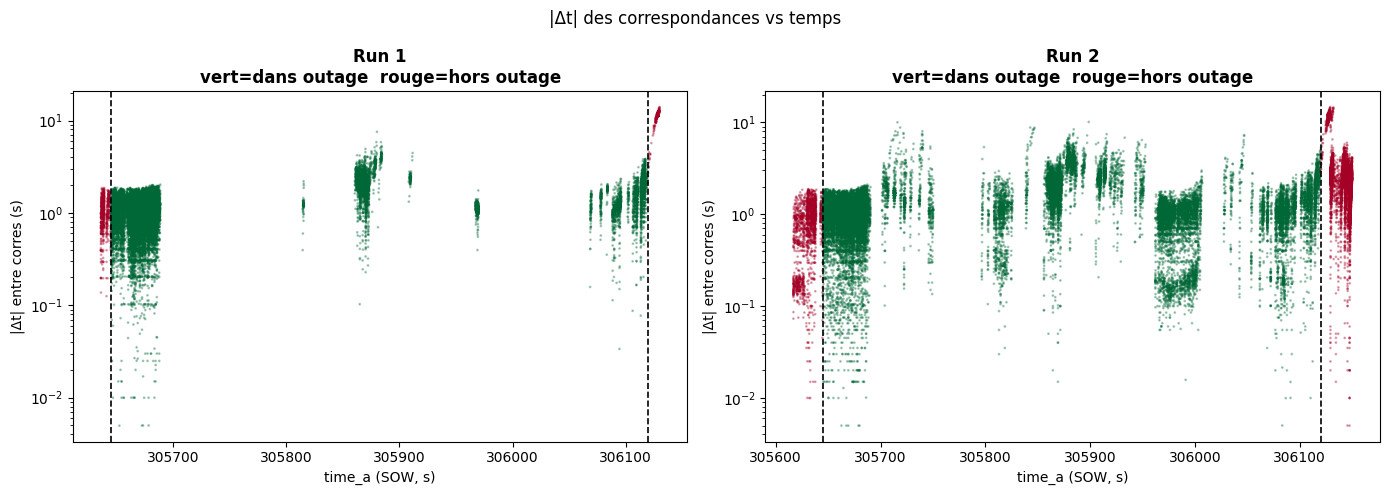

In [17]:
# ── CELL 4 — Analyse spatiale (scatter XY des points A) ──────
# Nécessite les fichiers corres_*.txt (avec XYZ) si disponibles,
# sinon on travaille avec les timestamps uniquement

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, df) in zip(axes, dfs.items()):
    color = COLORS[label]
    mask_in = (df.time_a >= T_OUTAGE_START) & (df.time_a <= T_OUTAGE_END)

    # Δt entre les deux points de chaque correspondance
    dt = (df.time_b - df.time_a).abs()

    sc = ax.scatter(df.time_a, dt, s=1, alpha=0.3, c=mask_in.astype(int),
                    cmap='RdYlGn', vmin=0, vmax=1)
    ax.axvline(T_OUTAGE_START, color='black', lw=1.2, ls='--')
    ax.axvline(T_OUTAGE_END,   color='black', lw=1.2, ls='--')
    ax.set_xlabel("time_a (SOW, s)")
    ax.set_ylabel("|Δt| entre corres (s)")
    ax.set_title(f"{label}\nvert=dans outage  rouge=hors outage", fontweight='bold')
    ax.set_yscale('log')

fig.suptitle("|Δt| des correspondances vs temps", fontsize=12)
fig.tight_layout()
plt.show()

Run 1 — angle dans l'outage :
  médiane=79.12°  Q95=94.92°  max=174.45°
  % angle > 90° : 26.6%
  % angle > 45° : 85.7%

Run 2 — angle dans l'outage :
  médiane=61.53°  Q95=94.72°  max=159.50°
  % angle > 90° : 15.1%
  % angle > 45° : 67.0%



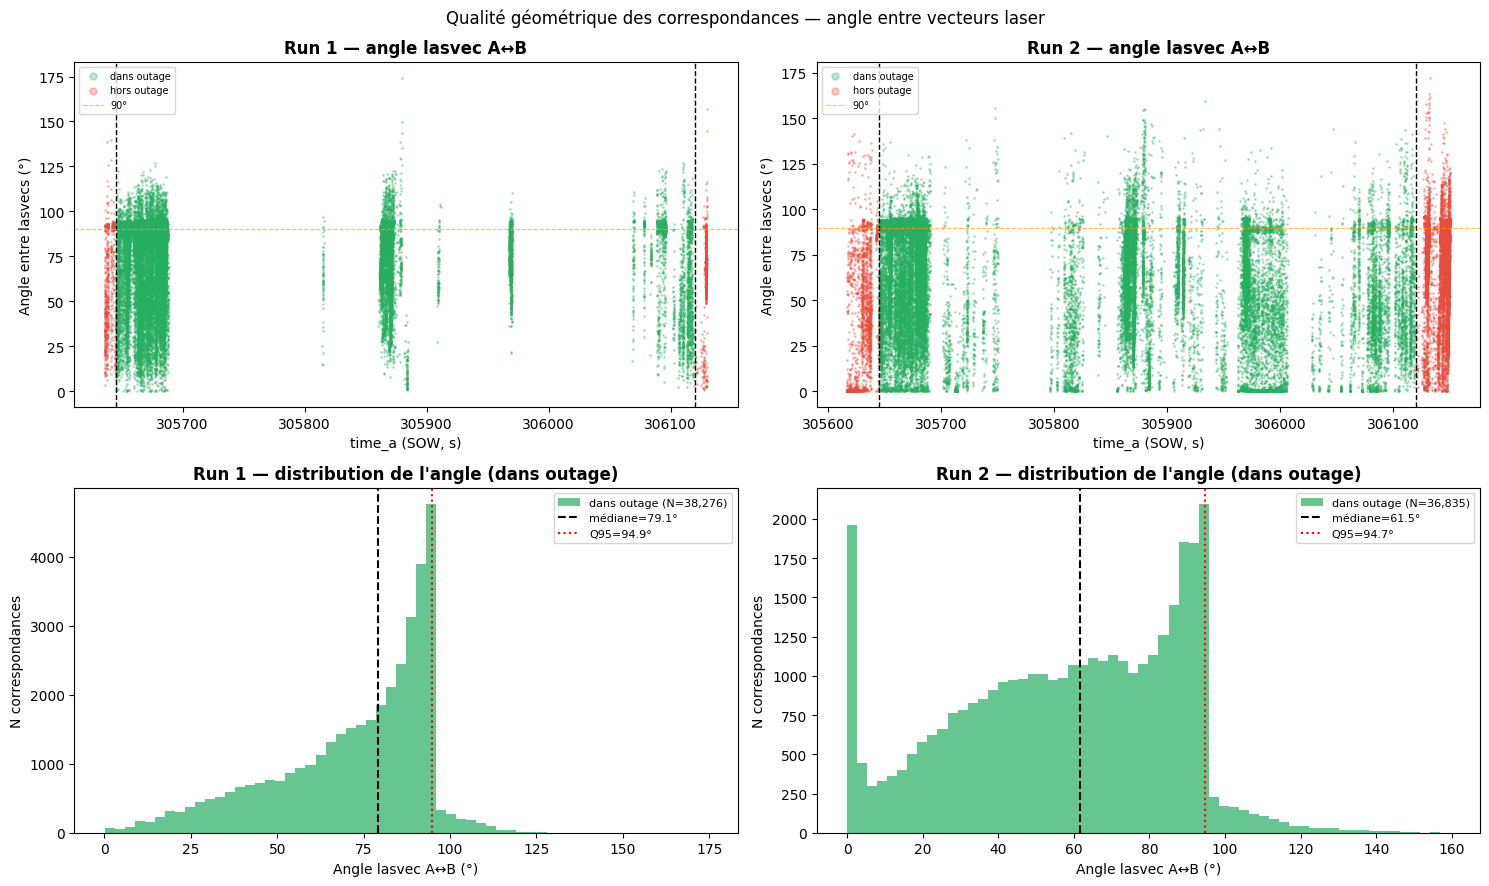

In [19]:
# ── CELL 5 — Qualité des correspondances : angle entre vecteurs laser ──
# dx_a/dy_a/dz_a et dx_b/dy_b/dz_b sont les directions des lasvecs
# Pour une bonne correspondance, les deux vecteurs doivent être quasi-parallèles
# (même surface vue depuis deux positions proches)
# Un grand angle → faux match ou géométrie incompatible

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

for col_i, (label, df) in enumerate(dfs.items()):
    # Normalise les vecteurs
    va = df[['dx_a','dy_a','dz_a']].values
    vb = df[['dx_b','dy_b','dz_b']].values
    va_n = va / np.linalg.norm(va, axis=1, keepdims=True)
    vb_n = vb / np.linalg.norm(vb, axis=1, keepdims=True)

    # Angle entre les deux vecteurs (en degrés)
    cos_angle = np.clip((va_n * vb_n).sum(axis=1), -1, 1)
    angle_deg = np.degrees(np.arccos(cos_angle))

    mask_in = (df.time_a >= T_OUTAGE_START) & (df.time_a <= T_OUTAGE_END)

    # Scatter : angle vs time_a
    ax = axes[0, col_i]
    ax.scatter(df.time_a[mask_in],  angle_deg[mask_in],
               s=1, alpha=0.3, color='#27ae60', label='dans outage')
    ax.scatter(df.time_a[~mask_in], angle_deg[~mask_in],
               s=1, alpha=0.3, color='#e74c3c', label='hors outage')
    ax.axvline(T_OUTAGE_START, color='black', lw=1, ls='--')
    ax.axvline(T_OUTAGE_END,   color='black', lw=1, ls='--')
    ax.axhline(90, color='orange', lw=0.8, ls='--', alpha=0.7, label='90°')
    ax.set_xlabel("time_a (SOW, s)")
    ax.set_ylabel("Angle entre lasvecs (°)")
    ax.set_title(f"{label} — angle lasvec A↔B", fontweight='bold')
    ax.legend(fontsize=7, markerscale=5)

    # Histogramme de l'angle dans l'outage seulement
    ax2 = axes[1, col_i]
    ax2.hist(angle_deg[mask_in], bins=60, color='#27ae60', alpha=0.7,
             label=f'dans outage (N={mask_in.sum():,})')
    ax2.axvline(np.median(angle_deg[mask_in]), color='black', lw=1.5,
                ls='--', label=f"médiane={np.median(angle_deg[mask_in]):.1f}°")
    ax2.axvline(np.percentile(angle_deg[mask_in], 95), color='red', lw=1.5,
                ls=':', label=f"Q95={np.percentile(angle_deg[mask_in], 95):.1f}°")
    ax2.set_xlabel("Angle lasvec A↔B (°)")
    ax2.set_ylabel("N correspondances")
    ax2.set_title(f"{label} — distribution de l'angle (dans outage)", fontweight='bold')
    ax2.legend(fontsize=8)

    print(f"{label} — angle dans l'outage :")
    print(f"  médiane={np.median(angle_deg[mask_in]):.2f}°  "
          f"Q95={np.percentile(angle_deg[mask_in], 95):.2f}°  "
          f"max={angle_deg[mask_in].max():.2f}°")
    print(f"  % angle > 90° : {100*(angle_deg[mask_in]>90).mean():.1f}%")
    print(f"  % angle > 45° : {100*(angle_deg[mask_in]>45).mean():.1f}%")
    print()

fig.suptitle("Qualité géométrique des correspondances — angle entre vecteurs laser",
             fontsize=12)
fig.tight_layout()
plt.show()

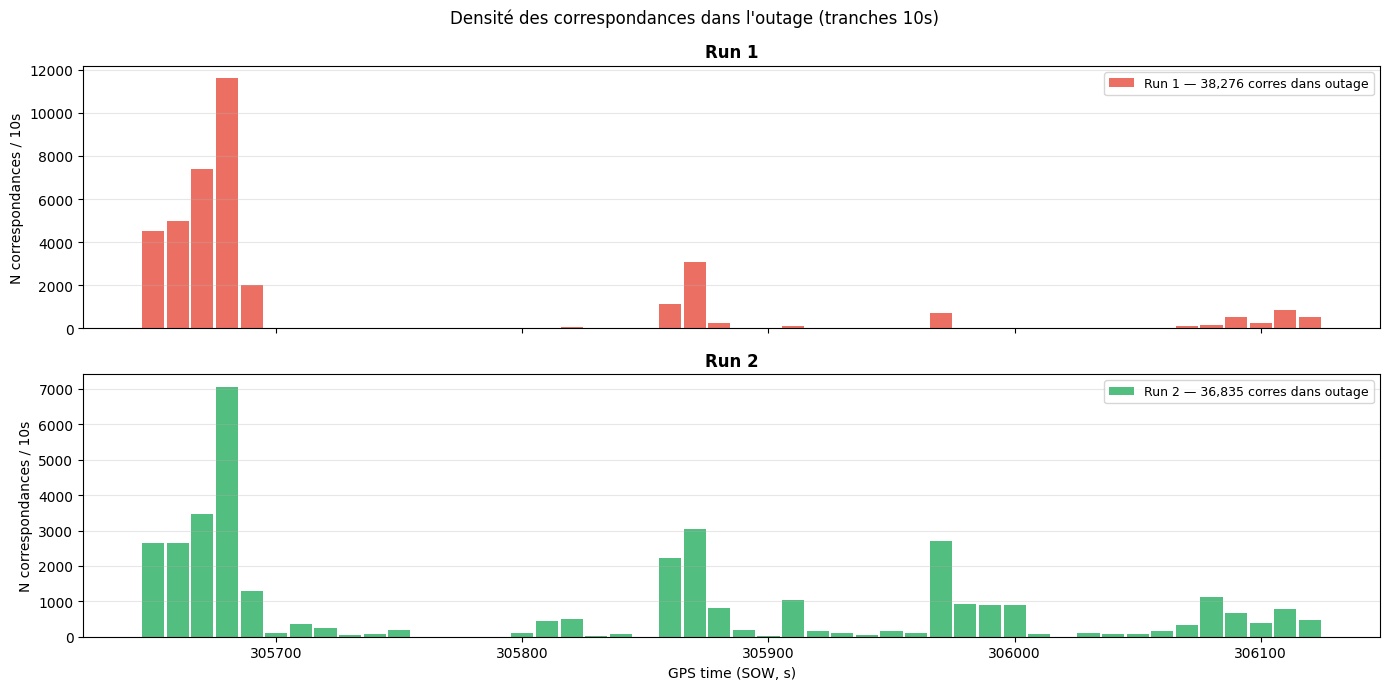

In [20]:
# ── CELL 6 — Résumé : densité de corres par tranche de 10s ───────────────
# Montre côte à côte Run1 vs Run2 pour voir exactement où chacun a des corres

bins = np.arange(T_OUTAGE_START, T_OUTAGE_END + 10, 10)
bin_centers = (bins[:-1] + bins[1:]) / 2

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, (label, df) in zip(axes, dfs.items()):
    mask_in = (df.time_a >= T_OUTAGE_START) & (df.time_a <= T_OUTAGE_END)
    counts, _ = np.histogram(df.time_a[mask_in], bins=bins)

    color = '#e74c3c' if 'Run 1' in label else '#27ae60'
    ax.bar(bin_centers, counts, width=9, color=color, alpha=0.8,
           label=f"{label} — {mask_in.sum():,} corres dans outage")
    ax.set_ylabel("N correspondances / 10s")
    ax.set_title(f"{label}", fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_xlabel("GPS time (SOW, s)")
fig.suptitle("Densité des correspondances dans l'outage (tranches 10s)",
             fontsize=12)
fig.tight_layout()
plt.show()

Run 1 — Δt dans outage :
  médiane=1.193 s  Q25=0.980 s  Q75=1.443 s  Q95=2.278 s  max=7.550 s

Run 2 — Δt dans outage :
  médiane=1.187 s  Q25=0.884 s  Q75=1.604 s  Q95=2.878 s  max=10.101 s



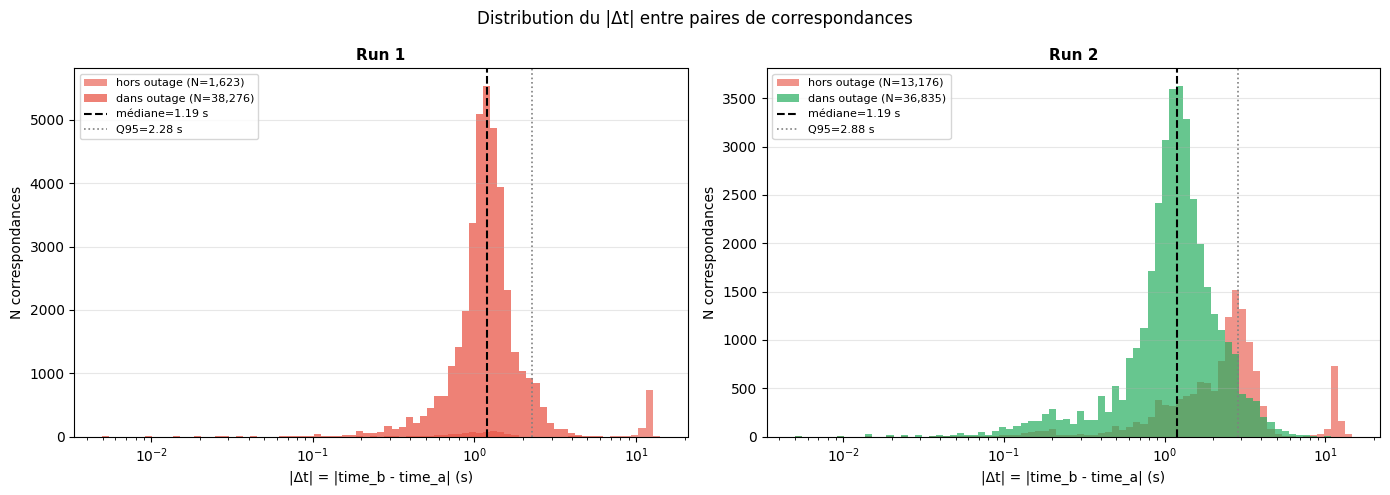

In [21]:
# Histogramme du Δt entre time_a et time_b pour chaque correspondance

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, (label, df) in zip(axes, dfs.items()):
    color = '#e74c3c' if 'Run 1' in label else '#27ae60'
    
    dt = (df.time_b - df.time_a).abs()
    mask_in = (df.time_a >= T_OUTAGE_START) & (df.time_a <= T_OUTAGE_END)
    
    dt_in  = dt[mask_in]
    dt_out = dt[~mask_in]
    
    bins = np.logspace(np.log10(dt[dt>0].min()), np.log10(dt.max()), 80)
    
    ax.hist(dt_out, bins=bins, color='#e74c3c', alpha=0.6, label=f'hors outage (N={(~mask_in).sum():,})')
    ax.hist(dt_in,  bins=bins, color=color,     alpha=0.7, label=f'dans outage (N={mask_in.sum():,})')
    
    ax.axvline(dt_in.median(), color='black', lw=1.5, ls='--',
               label=f'médiane={dt_in.median():.2f} s')
    ax.axvline(dt_in.quantile(0.95), color='gray', lw=1.2, ls=':',
               label=f'Q95={dt_in.quantile(0.95):.2f} s')
    
    ax.set_xscale('log')
    ax.set_xlabel('|Δt| = |time_b - time_a| (s)', fontsize=10)
    ax.set_ylabel('N correspondances', fontsize=10)
    ax.set_title(f'{label}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    
    print(f"{label} — Δt dans outage :")
    print(f"  médiane={dt_in.median():.3f} s  "
          f"Q25={dt_in.quantile(0.25):.3f} s  "
          f"Q75={dt_in.quantile(0.75):.3f} s  "
          f"Q95={dt_in.quantile(0.95):.3f} s  "
          f"max={dt_in.max():.3f} s")
    print()

fig.suptitle('Distribution du |Δt| entre paires de correspondances', fontsize=12)
fig.tight_layout()
plt.show()

Run 1 — S2S court : 82 corres dans outage (0.2% du total outage)
Run 2 — S2S court : 406 corres dans outage (1.1% du total outage)






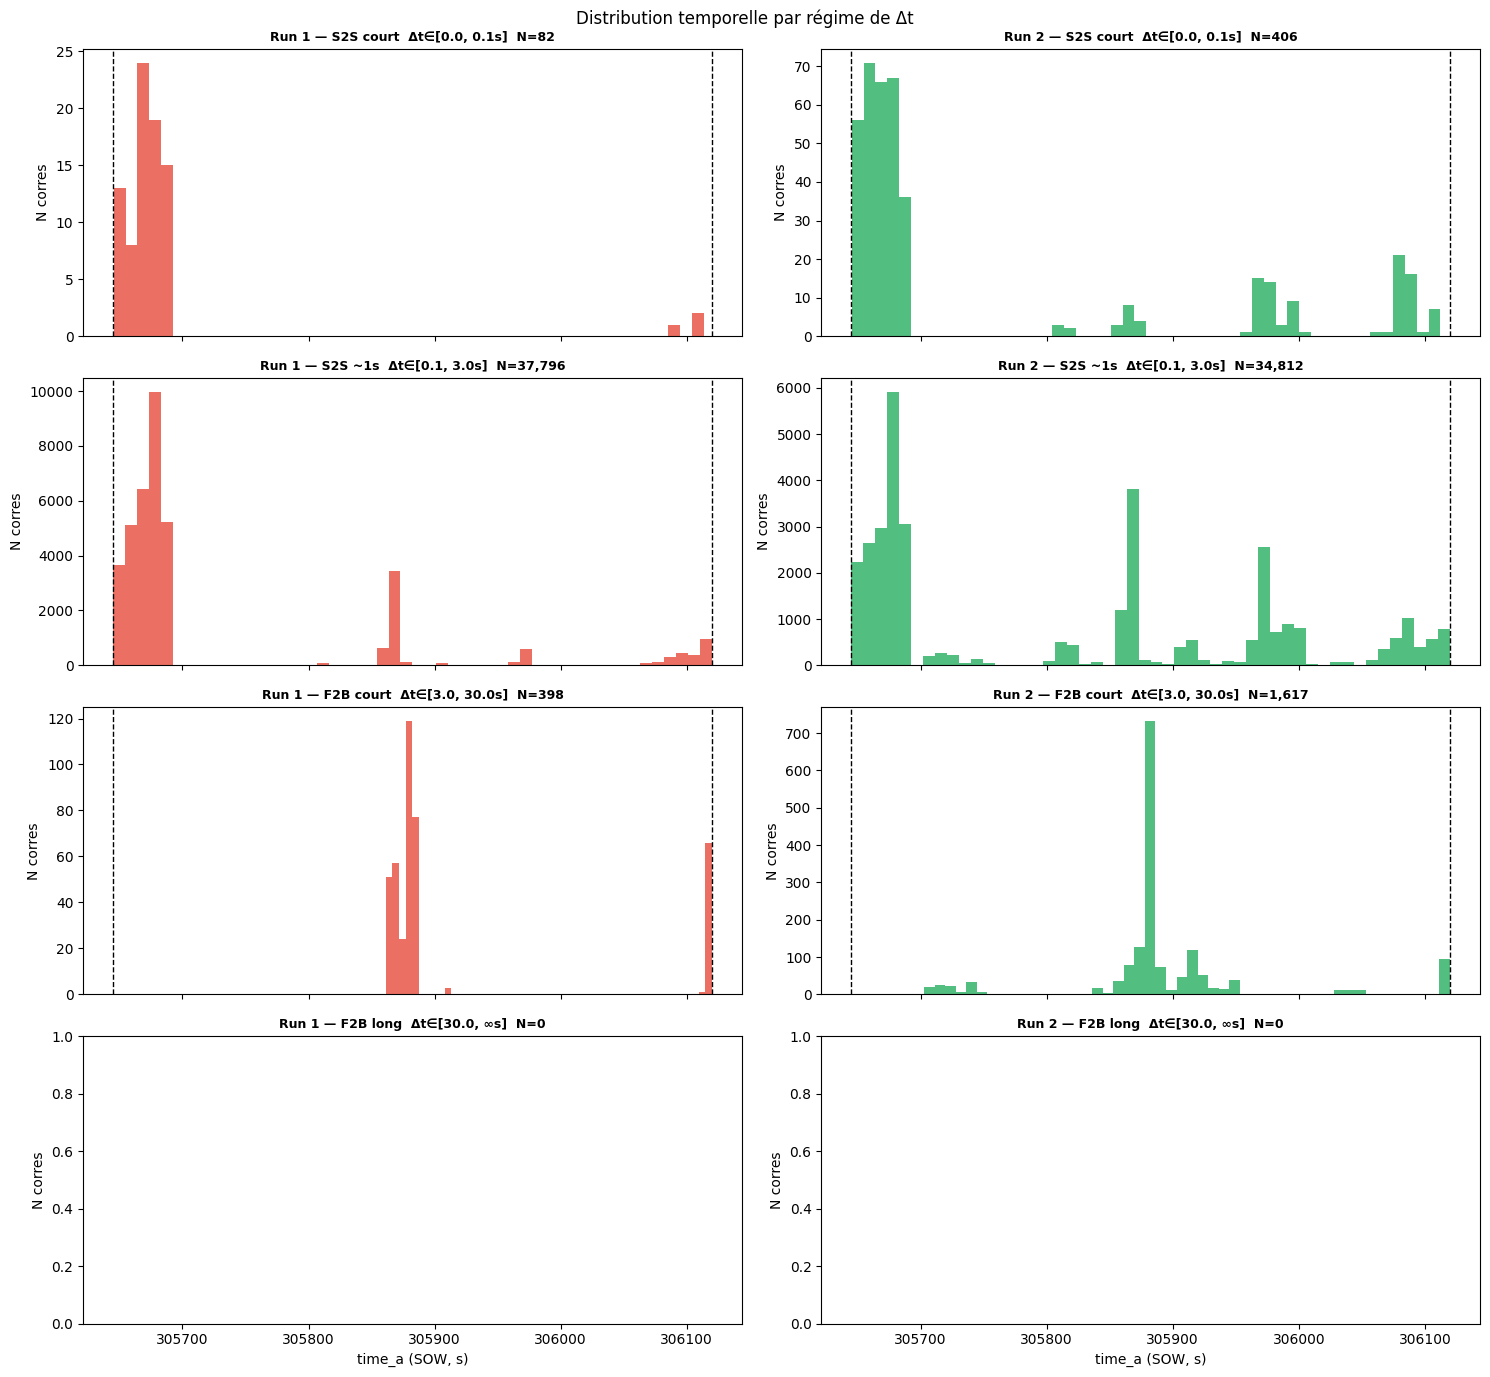

In [22]:
# Décompose les correspondances par régime de Δt
# et montre la distribution temporelle de chaque régime

REGIMES = [
    ('S2S court',   0,     0.1),    # même scan ou quasi
    ('S2S ~1s',     0.1,   3.0),    # scan consécutifs typiques
    ('F2B court',   3.0,   30.0),   # crossings proches
    ('F2B long',    30.0,  np.inf), # crossings lointains
]

fig, axes = plt.subplots(len(REGIMES), 2, figsize=(15, 3.5*len(REGIMES)),
                         sharex='col', sharey=False)

for ri, (regime_label, dt_lo, dt_hi) in enumerate(REGIMES):
    for ci, (label, df) in enumerate(dfs.items()):
        ax = axes[ri, ci]
        color = '#e74c3c' if 'Run 1' in label else '#27ae60'

        dt   = (df.time_b - df.time_a).abs()
        mask_regime = (dt >= dt_lo) & (dt < dt_hi)
        mask_in     = (df.time_a >= T_OUTAGE_START) & (df.time_a <= T_OUTAGE_END)
        mask        = mask_regime & mask_in

        n = mask.sum()
        if n > 0:
            ax.hist(df.time_a[mask], bins=50, color=color, alpha=0.8)
            ax.axvline(T_OUTAGE_START, color='black', lw=1, ls='--')
            ax.axvline(T_OUTAGE_END,   color='black', lw=1, ls='--')

        ax.set_title(f"{label} — {regime_label}  "
                     f"Δt∈[{dt_lo:.1f}, {dt_hi if dt_hi!=np.inf else '∞'}s]  "
                     f"N={n:,}", fontsize=9, fontweight='bold')
        ax.set_ylabel("N corres")
        if ri == len(REGIMES)-1:
            ax.set_xlabel("time_a (SOW, s)")

        if ri == 0:
            print(f"{label} — {regime_label} : {n:,} corres dans outage "
                  f"({100*n/len(df[mask_in]):.1f}% du total outage)")

    print()

fig.suptitle("Distribution temporelle par régime de Δt", fontsize=12)
fig.tight_layout()
plt.show()

In [26]:
import pandas as pd
from pathlib import Path

P2P_PATH = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/F2B/in/LiDAR_p2p.txt")

df = pd.read_csv(P2P_PATH, header=None)
df_sorted = df.sort_values(0).reset_index(drop=True)

out_path = P2P_PATH.parent / (P2P_PATH.stem + "_sorted.txt")
df_sorted.to_csv(out_path, header=False, index=False, float_format='%.9f')
print(f"{len(df_sorted):,} lignes → {out_path}")

39,899 lignes → /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/F2B/in/LiDAR_p2p_sorted.txt


In [24]:
import pandas as pd
import numpy as np
from pathlib import Path

# ── Fichiers source ───────────────────────────────────────────
P2P_BEST  = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/F2B/in/LiDAR_p2p.txt")   # Run 1 — base
P2P_OTHER = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/F2B/v3_in/LiDAR_p2p.txt")   # Run 2 — complément
P2P_OUT   = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/F2B/v4_in/LiDAR_p2p.txt")

COLS = ['time_a', 'time_b', 'dx_a', 'dy_a', 'dz_a', 'dx_b', 'dy_b', 'dz_b']

df_best  = pd.read_csv(P2P_BEST,  header=None, names=COLS)
df_other = pd.read_csv(P2P_OTHER, header=None, names=COLS)

# ── Zones à compléter depuis Run 2 ───────────────────────────
FILL_ZONES = [
    (305700.0, 305840.0),
    (305980.0, 306050.0),
]

# ── Extraction des zones manquantes depuis Run 2 ──────────────
fill_parts = []
for t0, t1 in FILL_ZONES:
    mask = (df_other.time_a >= t0) & (df_other.time_a <= t1)
    n = mask.sum()
    print(f"  [{t0:.0f}, {t1:.0f}]  → {n:,} corres depuis Run 2")
    fill_parts.append(df_other[mask])

# ── Merge et tri ──────────────────────────────────────────────
df_mixed = pd.concat([df_best] + fill_parts, ignore_index=True)
df_mixed = df_mixed.sort_values('time_a').reset_index(drop=True)

df_mixed.to_csv(P2P_OUT, header=False, index=False, float_format='%.9f')

print(f"\nRun 1  : {len(df_best):,} corres")
print(f"Ajouté : {sum(len(f) for f in fill_parts):,} corres")
print(f"Total  : {len(df_mixed):,} corres → {P2P_OUT.name}")

  [305700, 305840]  → 3,587 corres depuis Run 2
  [305980, 306050]  → 3,564 corres depuis Run 2

Run 1  : 39,899 corres
Ajouté : 7,151 corres
Total  : 47,050 corres → LiDAR_p2p.txt


In [25]:
# Correspondances communes aux deux fichiers
# Une correspondance est "commune" si (time_a, time_b) est identique dans les deux

common = pd.merge(
    df_best[['time_a', 'time_b']],
    df_other[['time_a', 'time_b']],
    on=['time_a', 'time_b'],
    how='inner'
)

print(f"Run 1  : {len(df_best):,} corres")
print(f"Run 2  : {len(df_other):,} corres")
print(f"Communes (time_a + time_b identiques) : {len(common):,}")
print(f"  → {100*len(common)/len(df_best):.1f}% de Run 1")
print(f"  → {100*len(common)/len(df_other):.1f}% de Run 2")

Run 1  : 39,899 corres
Run 2  : 62,233 corres
Communes (time_a + time_b identiques) : 1,196
  → 3.0% de Run 1
  → 1.9% de Run 2
